**PS: A detailed report on EDA is provided in a separate file, kindly check README.md**

# Module Imports and Notebook Settings


In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
%matplotlib inline
mpl.rcParams.update(
    {
        "figure.dpi": 150,
        "figure.facecolor": "white",
        "figure.edgecolor": "none",
        "axes.facecolor": "#f8f9fa",
        "axes.edgecolor": "#333333",
        "axes.linewidth": 1.5,
        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "font.size": 11,
        "font.family": "sans-serif",
        "font.sans-serif": ["Segoe UI", "Arial", "Helvetica", "sans-serif"],
        "grid.color": "#d0d0d0",
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.5,
        "lines.linewidth": 2.5,
        "patch.edgecolor": "white",
        "patch.linewidth": 1.5,
    }
)

sns.set_style(
    "whitegrid",
    {
        "axes.facecolor": "#f8f9fa",
        "axes.edgecolor": "#333333",
        "grid.color": "#d0d0d0",
        "axes.linewidth": 1.5,
    },
)

sns.set_context("notebook", font_scale=1.1)

sns.set_palette("Set2")


# Artefacts Loading


In [3]:
df = pd.read_csv("../artifacts/data/02-preprocessed/train_df.csv")
df.head(2)

,url,house_type,bathrooms,bedrooms,price,locality,lat,lng,condition,furnishing,24_hour_electricity,air_conditioning,apartment,balcony,chandelier,dining_area,dishwasher,hot_water,kitchen_cabinets,kitchen_shelf,microwave,pop_ceiling,pre_paid_meter,refrigerator,tv,tiled_floor,wardrobe,wi_fi
0,https://jiji.com.gh/manet-junction/houses-apar...,Apartment,2,3,8000.0,Spintex,5.637614,-0.126606,New,Unfurnished,1,1,0,1,1,0,0,1,1,1,0,1,1,0,0,1,1,0
1,https://jiji.com.gh/airport-residential-area/h...,Apartment,2,2,6000.0,Airport Residential Area,5.606105,-0.186036,New,Semi-Furnished,1,1,1,1,0,0,0,1,1,0,0,1,1,0,0,1,1,0


# Exploratory Analysis Of The Training Set


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,12460.0,2.636116,1.506871,1.000000,1.000000,2.000000,4.000000,20.00000
bedrooms,12460.0,2.546950,1.415278,1.000000,2.000000,2.000000,3.000000,20.00000
price,12460.0,10725.537560,15416.373820,160.000000,2200.000000,4500.000000,12400.000000,176000.00000
lat,12460.0,5.779447,1.785080,5.532814,5.583166,5.635828,5.669425,36.97880
lng,12460.0,0.013789,3.120399,-25.105905,-0.217044,-0.161359,-0.126606,39.60245
24_hour_electricity,12460.0,0.743660,0.436629,0.000000,0.000000,1.000000,1.000000,1.00000
air_conditioning,12460.0,0.494302,0.499988,0.000000,0.000000,0.000000,1.000000,1.00000
apartment,12460.0,0.127769,0.333846,0.000000,0.000000,0.000000,0.000000,1.00000
balcony,12460.0,0.542215,0.498235,0.000000,0.000000,1.000000,1.000000,1.00000
chandelier,12460.0,0.281942,0.449963,0.000000,0.000000,0.000000,1.000000,1.00000


## Price Analysis


In [5]:
df.price.describe().T

count     12460.00000
mean      10725.53756
std       15416.37382
min         160.00000
25%        2200.00000
50%        4500.00000
75%       12400.00000
max      176000.00000
Name: price, dtype: float64

## Location Analysis


In [6]:
top_cities = df["locality"].value_counts().head(20).index
df_top_cities = (
    df[df["locality"].isin(top_cities)]["locality"]
    .value_counts()
    .to_frame()
    .reset_index()
)
df_top_cities

,locality,count
0,East Legon,1378
1,Spintex,1039
2,Teshie,1024
3,Adenta,708
4,Accra Metropolitan,683
5,Tema Metropolitan,650
6,Ashaley Botwe,493
7,Airport Residential Area,450
8,Adjiriganor,449
9,Weija,426


In [7]:
locality_table = []
n = 20

top_locality = df["locality"].value_counts().index[:n]
for b in top_locality:
    locality_table.append(df[df["locality"] == b]["price"].describe().T)

pd.DataFrame(locality_table, index=df["locality"].value_counts().index[:n]).sort_values(
    by="mean", ascending=False
)


,count,mean,std,min,25%,50%,75%,max
locality,,,,,,,,
Cantonments,306.0,50012.843137,24437.712320,4200.0,33525.0,45950.0,61175.0,152000.0
Airport Residential Area,450.0,33292.440000,25304.651240,1200.0,15000.0,27800.0,46695.0,150000.0
East Legon,1378.0,19255.642235,17642.305356,300.0,7000.0,14000.0,26000.0,169874.0
Adjiriganor,449.0,13196.093541,13034.283679,800.0,4000.0,8500.0,18000.0,84000.0
Accra Metropolitan,683.0,12022.715959,13618.357034,300.0,3500.0,8000.0,15560.5,150000.0
Spintex,1039.0,9182.102984,8049.345646,450.0,3500.0,7000.0,12443.0,60000.0
Teshie,1024.0,8514.205078,10932.414060,350.0,1700.0,4000.0,10425.0,91000.0
Tema Metropolitan,650.0,7598.947692,9960.291319,250.0,2500.0,4000.0,8000.0,113000.0
Achimota,341.0,7574.982405,8602.007404,300.0,1800.0,3800.0,11600.0,65000.0


# Plotting Functions


In [8]:
def plot_distribution(df, col, title=None, color="steelblue"):
    """Beautiful distribution plot with stats"""
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot histogram with KDE
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        color=color,
        ax=ax,
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
    )

    # Add statistics lines
    median = df[col].median()
    mean = df[col].mean()

    ax.axvline(
        median,
        ls="--",
        lw=2,
        color="darkred",
        label=f"Median: {median:,.0f}",
        alpha=0.8,
    )
    ax.axvline(
        mean, ls="--", lw=2, color="darkgreen", label=f"Mean: {mean:,.0f}", alpha=0.8
    )

    # Styling
    ax.set_xlabel(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=12, fontweight="bold")
    ax.set_title(
        title or f"Distribution of {col.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.ticklabel_format(axis="x", style="plain")
    sns.despine(trim=True)

    plt.tight_layout()
    plt.show()


def plot_combined_distribution(df, col):
    """Combined plot: original and log distribution side by side"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Original distribution
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        color="steelblue",
        ax=axes[0],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
    )
    median = df[col].median()
    axes[0].axvline(
        median,
        ls="--",
        lw=2,
        color="darkred",
        label=f"Median: {median:,.0f}",
        alpha=0.8,
    )
    axes[0].set_xlabel(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Frequency", fontsize=12, fontweight="bold")
    axes[0].set_title(f"Original Distribution", fontsize=13, fontweight="bold")
    axes[0].legend(frameon=True, fancybox=True, shadow=True)
    axes[0].ticklabel_format(axis="x", style="plain")
    sns.despine(ax=axes[0], trim=True)

    # Log distribution
    log_col = np.log(df[col])
    sns.histplot(
        log_col,
        bins=50,
        kde=True,
        color="coral",
        ax=axes[1],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
    )
    log_median = log_col.median()
    axes[1].axvline(
        log_median,
        ls="--",
        lw=2,
        color="darkred",
        label=f"Log Median: {log_median:.2f}",
        alpha=0.8,
    )
    axes[1].set_xlabel(
        f"Log({col.replace('_', ' ').title()})", fontsize=12, fontweight="bold"
    )
    axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")
    axes[1].set_title(f"Log-Transformed Distribution", fontsize=13, fontweight="bold")
    axes[1].legend(frameon=True, fancybox=True, shadow=True)
    sns.despine(ax=axes[1], trim=True)

    plt.suptitle(
        f"{col.replace('_', ' ').title()} Distribution Analysis",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


def plot_top_categories_pie(df, column, top_n=20, title=None):
    """Beautiful pie chart with top categories"""
    top_cats = df[column].value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Create explosion effect for top category
    explode = [0.1] + [0] * (len(top_cats) - 1)

    # Custom colors
    colors = sns.color_palette("Set3", len(top_cats))

    wedges, texts, autotexts = ax.pie(
        top_cats.values,
        labels=top_cats.index,
        explode=explode,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
        textprops={"fontsize": 10, "weight": "bold"},
        pctdistance=0.85,
    )

    # Make percentage text white and bold
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontsize(9)
        autotext.set_weight("bold")

    ax.set_title(
        title or f"Top {top_n} {column.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    plt.tight_layout()
    plt.show()


def plot_categorical_vs_numeric(df, cat_col, num_col, top_n=15, title=None):
    """Beautiful bar plot with sorted values"""
    # Get top categories by mean
    top_cats = (
        df.groupby(cat_col)[num_col].mean().nlargest(top_n).sort_values(ascending=True)
    )
    data = df[df[cat_col].isin(top_cats.index)]

    fig, ax = plt.subplots(figsize=(12, 8))

    # Calculate means for sorting
    means = data.groupby(cat_col)[num_col].mean().loc[top_cats.index]

    # Create horizontal bar plot
    bars = ax.barh(
        range(len(means)),
        means.values,
        color=sns.color_palette("viridis", len(means)),
        edgecolor="white",
        linewidth=1.5,
        alpha=0.85,
    )

    # Add value labels on bars
    for i, (idx, val) in enumerate(means.items()):
        ax.text(
            val + val * 0.01,
            i,
            f"{val:,.0f}",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=10)
    ax.set_xlabel(
        f"Average {num_col.replace('_', ' ').title()}", fontsize=12, fontweight="bold"
    )
    ax.set_ylabel(cat_col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_title(
        title
        or f"Top {top_n} {cat_col.replace('_', ' ').title()} by Average {num_col.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    # Add subtle grid
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()


def plot_count(df, column, top_n=None, title=None):
    """Beautiful count plot sorted by frequency"""
    if top_n:
        counts = df[column].value_counts().head(top_n).sort_values(ascending=True)
    else:
        counts = df[column].value_counts().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(counts) * 0.4)))

    # Create horizontal bar plot
    bars = ax.barh(
        range(len(counts)),
        counts.values,
        color=sns.color_palette("muted", len(counts)),
        edgecolor="white",
        linewidth=1.5,
        alpha=0.85,
    )

    # Add value labels
    for i, val in enumerate(counts.values):
        ax.text(
            val + val * 0.01, i, f"{val:,}", va="center", fontsize=10, fontweight="bold"
        )

    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=11)
    ax.set_xlabel("Count", fontsize=12, fontweight="bold")
    ax.set_ylabel(column.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_title(
        title or f"Distribution of {column.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    # Add subtle grid
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()


def plot_boxplot_by_category(df, cat_col, num_col, top_n=20, title=None):
    """Beautiful boxplot for categories"""
    # Get top categories by count
    top_cats = df[cat_col].value_counts().head(top_n).index
    data = df[df[cat_col].isin(top_cats)].copy()

    # Sort by median price
    order = data.groupby(cat_col)[num_col].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(16, 8))

    # Create boxplot
    sns.boxplot(
        data=data,
        x=cat_col,
        y=num_col,
        order=order,
        palette="Set2",
        width=0.6,
        ax=ax,
        flierprops=dict(marker="o", markerfacecolor="red", markersize=4, alpha=0.5),
    )

    ax.set_xlabel(cat_col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_ylabel(num_col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_title(
        title
        or f"{num_col.replace('_', ' ').title()} Distribution by {cat_col.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.xticks(rotation=45, ha="right")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

    # Add subtle grid
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine()

    plt.tight_layout()
    plt.show()


def plot_combined_categorical_analysis(df, cat_col, num_col, top_n=10):
    """Combined plot: count + average price for categories"""
    # Get data
    counts = df[cat_col].value_counts().head(top_n).sort_values(ascending=True)
    means = df.groupby(cat_col)[num_col].mean().loc[counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot 1: Count
    bars1 = axes[0].barh(
        range(len(counts)),
        counts.values,
        color=sns.color_palette("Blues_d", len(counts)),
        edgecolor="white",
        linewidth=1.5,
        alpha=0.85,
    )

    for i, val in enumerate(counts.values):
        axes[0].text(
            val + val * 0.02, i, f"{val:,}", va="center", fontsize=10, fontweight="bold"
        )

    axes[0].set_yticks(range(len(counts)))
    axes[0].set_yticklabels(counts.index, fontsize=11)
    axes[0].set_xlabel("Count", fontsize=12, fontweight="bold")
    axes[0].set_title(f"Frequency", fontsize=13, fontweight="bold")
    axes[0].grid(axis="x", alpha=0.3, linestyle="--")
    axes[0].set_axisbelow(True)
    sns.despine(ax=axes[0], left=True, bottom=True)

    # Plot 2: Average Price (sorted by price)
    means_sorted = means.sort_values(ascending=True)
    bars2 = axes[1].barh(
        range(len(means_sorted)),
        means_sorted.values,
        color=sns.color_palette("Greens_d", len(means_sorted)),
        edgecolor="white",
        linewidth=1.5,
        alpha=0.85,
    )

    for i, val in enumerate(means_sorted.values):
        axes[1].text(
            val + val * 0.02,
            i,
            f"{val:,.0f}",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

    axes[1].set_yticks(range(len(means_sorted)))
    axes[1].set_yticklabels(means_sorted.index, fontsize=11)
    axes[1].set_xlabel(
        f"Average {num_col.replace('_', ' ').title()}", fontsize=12, fontweight="bold"
    )
    axes[1].set_title(
        f"Average {num_col.replace('_', ' ').title()}", fontsize=13, fontweight="bold"
    )
    axes[1].grid(axis="x", alpha=0.3, linestyle="--")
    axes[1].set_axisbelow(True)
    sns.despine(ax=axes[1], left=True, bottom=True)

    plt.suptitle(
        f"{cat_col.replace('_', ' ').title()} Analysis",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df, figsize=(14, 10)):
    """Beautiful correlation heatmap"""
    # Get numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])

    # Calculate correlation
    corr = numeric_df.corr()

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=figsize)

    # Create heatmap
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=1.5,
        cbar_kws={"shrink": 0.8, "label": "Correlation"},
        ax=ax,
        vmin=-1,
        vmax=1,
        annot_kws={"fontsize": 9, "fontweight": "bold"},
    )

    ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=16, pad=20)

    plt.xticks(rotation=45, ha="right", fontweight="bold")
    plt.yticks(rotation=0, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_price_vs_rooms(df):
    """Price relationship with bedrooms and bathrooms"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bedrooms vs Price
    bedroom_stats = df.groupby("bedrooms")["price"].agg(["mean", "median", "count"])
    bedroom_stats = bedroom_stats[bedroom_stats["count"] >= 10]  # Filter low counts

    axes[0].plot(
        bedroom_stats.index,
        bedroom_stats["mean"],
        marker="o",
        linewidth=3,
        markersize=10,
        label="Mean",
        color="#4E79A7",
    )
    axes[0].plot(
        bedroom_stats.index,
        bedroom_stats["median"],
        marker="s",
        linewidth=3,
        markersize=10,
        label="Median",
        color="#F28E2B",
    )

    axes[0].set_xlabel("Number of Bedrooms", fontweight="bold")
    axes[0].set_ylabel("Price (GH₵)", fontweight="bold")
    axes[0].set_title("Price vs Bedrooms", fontweight="bold", fontsize=14)
    axes[0].legend(frameon=True, shadow=True)
    axes[0].grid(True, alpha=0.3, linestyle="--")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

    # Bathrooms vs Price
    bathroom_stats = df.groupby("bathrooms")["price"].agg(["mean", "median", "count"])
    bathroom_stats = bathroom_stats[bathroom_stats["count"] >= 10]

    axes[1].plot(
        bathroom_stats.index,
        bathroom_stats["mean"],
        marker="o",
        linewidth=3,
        markersize=10,
        label="Mean",
        color="#4E79A7",
    )
    axes[1].plot(
        bathroom_stats.index,
        bathroom_stats["median"],
        marker="s",
        linewidth=3,
        markersize=10,
        label="Median",
        color="#F28E2B",
    )

    axes[1].set_xlabel("Number of Bathrooms", fontweight="bold")
    axes[1].set_ylabel("Price (GH₵)", fontweight="bold")
    axes[1].set_title("Price vs Bathrooms", fontweight="bold", fontsize=14)
    axes[1].legend(frameon=True, shadow=True)
    axes[1].grid(True, alpha=0.3, linestyle="--")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

    plt.suptitle("Room Count Impact on Price", fontweight="bold", fontsize=16, y=1.00)

    for ax in axes:
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()


def plot_amenity_price_impact(df, amenity_cols):
    """Compare prices with/without each amenity"""
    results = []

    for col in amenity_cols:
        if col in df.columns:
            with_amenity = df[df[col] == 1]["price"].median()
            without_amenity = df[df[col] == 0]["price"].median()
            difference = with_amenity - without_amenity
            pct_increase = (difference / without_amenity) * 100

            results.append(
                {
                    "amenity": col.replace("_", " ").title(),
                    "with": with_amenity,
                    "without": without_amenity,
                    "difference": difference,
                    "pct_increase": pct_increase,
                }
            )

    results_df = pd.DataFrame(results).sort_values("difference", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Color by positive/negative impact
    colors = ["#06A77D" if x > 0 else "#E15759" for x in results_df["difference"]]

    bars = ax.barh(
        range(len(results_df)),
        results_df["difference"],
        color=colors,
        edgecolor="white",
        linewidth=2,
        alpha=0.85,
    )

    # Add percentage labels
    for i, (diff, pct) in enumerate(
        zip(results_df["difference"], results_df["pct_increase"])
    ):
        label = f"{diff:,.0f} ({pct:+.1f}%)"
        x_pos = diff + (abs(diff) * 0.05) if diff > 0 else diff - (abs(diff) * 0.05)
        ha = "left" if diff > 0 else "right"
        ax.text(x_pos, i, label, va="center", ha=ha, fontsize=9, fontweight="bold")

    ax.set_yticks(range(len(results_df)))
    ax.set_yticklabels(results_df["amenity"], fontweight="bold")
    ax.set_xlabel("Price Difference (GH₵)", fontweight="bold")
    ax.set_title(
        "Amenity Impact on Median Price", fontweight="bold", fontsize=15, pad=20
    )
    ax.axvline(x=0, color="black", linewidth=1.5, linestyle="-")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()


def plot_violin_by_categories(df, cat_col, num_col, hue_col=None):
    """Beautiful violin plot showing distribution"""
    fig, ax = plt.subplots(figsize=(14, 7))

    # Sort categories by median
    order = df.groupby(cat_col)[num_col].median().sort_values(ascending=False).index

    sns.violinplot(
        data=df,
        x=cat_col,
        y=num_col,
        hue=hue_col,
        order=order,
        palette="Set2",
        cut=0,
        inner="quartile",
        ax=ax,
        linewidth=1.5,
    )

    ax.set_xlabel(cat_col.replace("_", " ").title(), fontweight="bold")
    ax.set_ylabel(num_col.replace("_", " ").title(), fontweight="bold")
    ax.set_title(
        f"{num_col.replace('_', ' ').title()} Distribution by {cat_col.replace('_', ' ').title()}",
        fontweight="bold",
        fontsize=15,
        pad=20,
    )
    plt.xticks(rotation=45, ha="right", fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    sns.despine()

    plt.tight_layout()
    plt.show()


def plot_outliers_analysis(df, column="price"):
    """Identify and visualize outliers"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original boxplot
    bp1 = axes[0].boxplot(
        df[column],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#4E79A7", alpha=0.7),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[0].set_ylabel(column.replace("_", " ").title(), fontweight="bold")
    axes[0].set_title("Box Plot with Outliers", fontweight="bold", fontsize=13)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
    axes[0].grid(axis="y", alpha=0.3, linestyle="--")

    # Z-score analysis
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > 3]

    axes[1].scatter(
        range(len(df)), df[column], alpha=0.5, s=20, label="Normal", color="#4E79A7"
    )
    axes[1].scatter(
        outliers.index,
        outliers[column],
        alpha=0.8,
        s=50,
        label=f"Outliers (n={len(outliers)})",
        color="#E15759",
    )
    axes[1].set_xlabel("Index", fontweight="bold")
    axes[1].set_ylabel(column.replace("_", " ").title(), fontweight="bold")
    axes[1].set_title("Z-Score Outlier Detection", fontweight="bold", fontsize=13)
    axes[1].legend(frameon=True, shadow=True)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
    axes[1].grid(alpha=0.3, linestyle="--")

    # IQR method
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    axes[2].hist(df[column], bins=50, alpha=0.7, color="#4E79A7", edgecolor="white")
    axes[2].axvline(
        lower_bound, color="red", linestyle="--", linewidth=2, label="IQR Bounds"
    )
    axes[2].axvline(upper_bound, color="red", linestyle="--", linewidth=2)
    axes[2].set_xlabel(column.replace("_", " ").title(), fontweight="bold")
    axes[2].set_ylabel("Frequency", fontweight="bold")
    axes[2].set_title(
        f"IQR Method (n={len(iqr_outliers)} outliers)", fontweight="bold", fontsize=13
    )
    axes[2].legend(frameon=True, shadow=True)
    axes[2].grid(alpha=0.3, linestyle="--")

    for ax in axes:
        ax.set_axisbelow(True)
        sns.despine(ax=ax)

    plt.suptitle(
        f"{column.replace('_', ' ').title()} Outlier Analysis",
        fontweight="bold",
        fontsize=16,
        y=1.00,
    )
    plt.tight_layout()
    plt.show()

    print(f"\nOutlier Summary:")
    print(
        f"Z-score method (>3): {len(outliers)} outliers ({len(outliers) / len(df) * 100:.2f}%)"
    )
    print(
        f"IQR method: {len(iqr_outliers)} outliers ({len(iqr_outliers) / len(df) * 100:.2f}%)"
    )


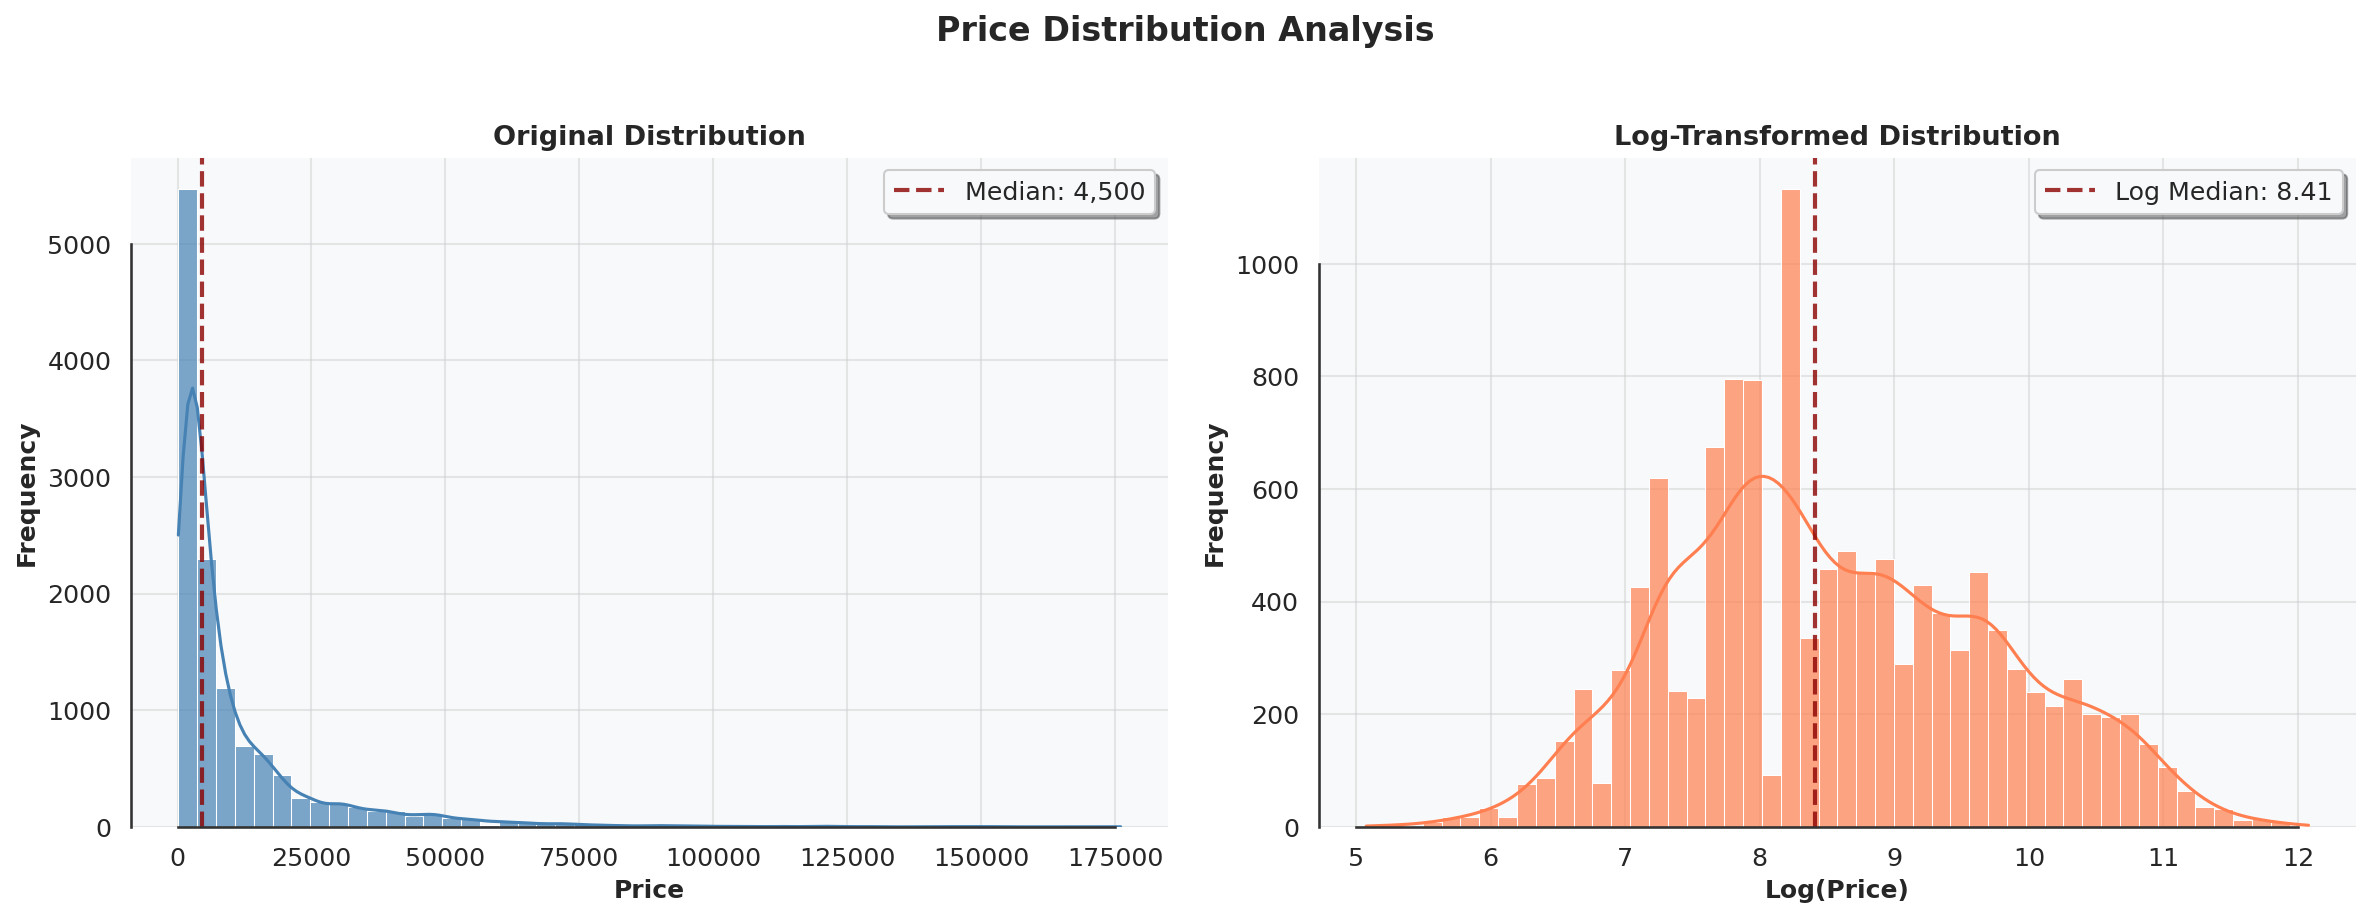

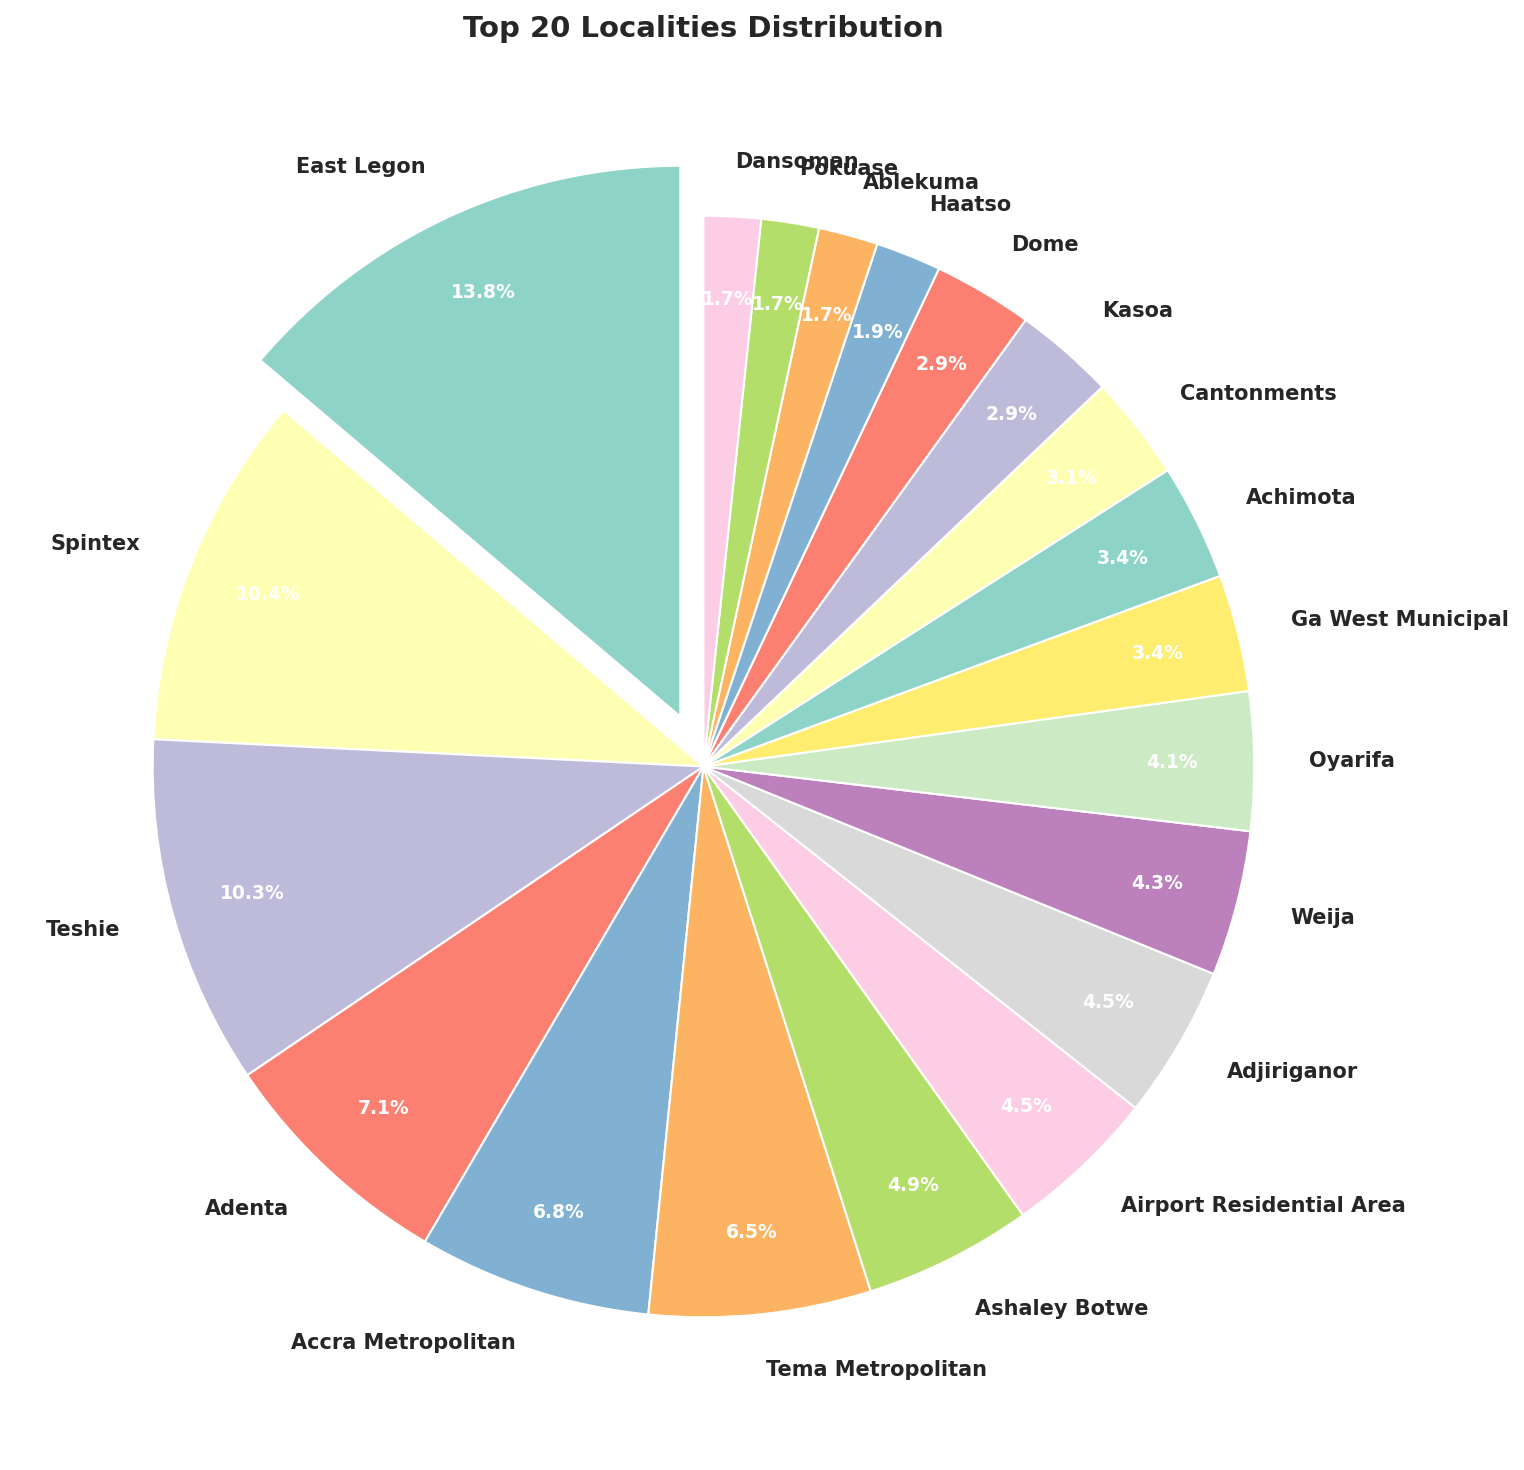

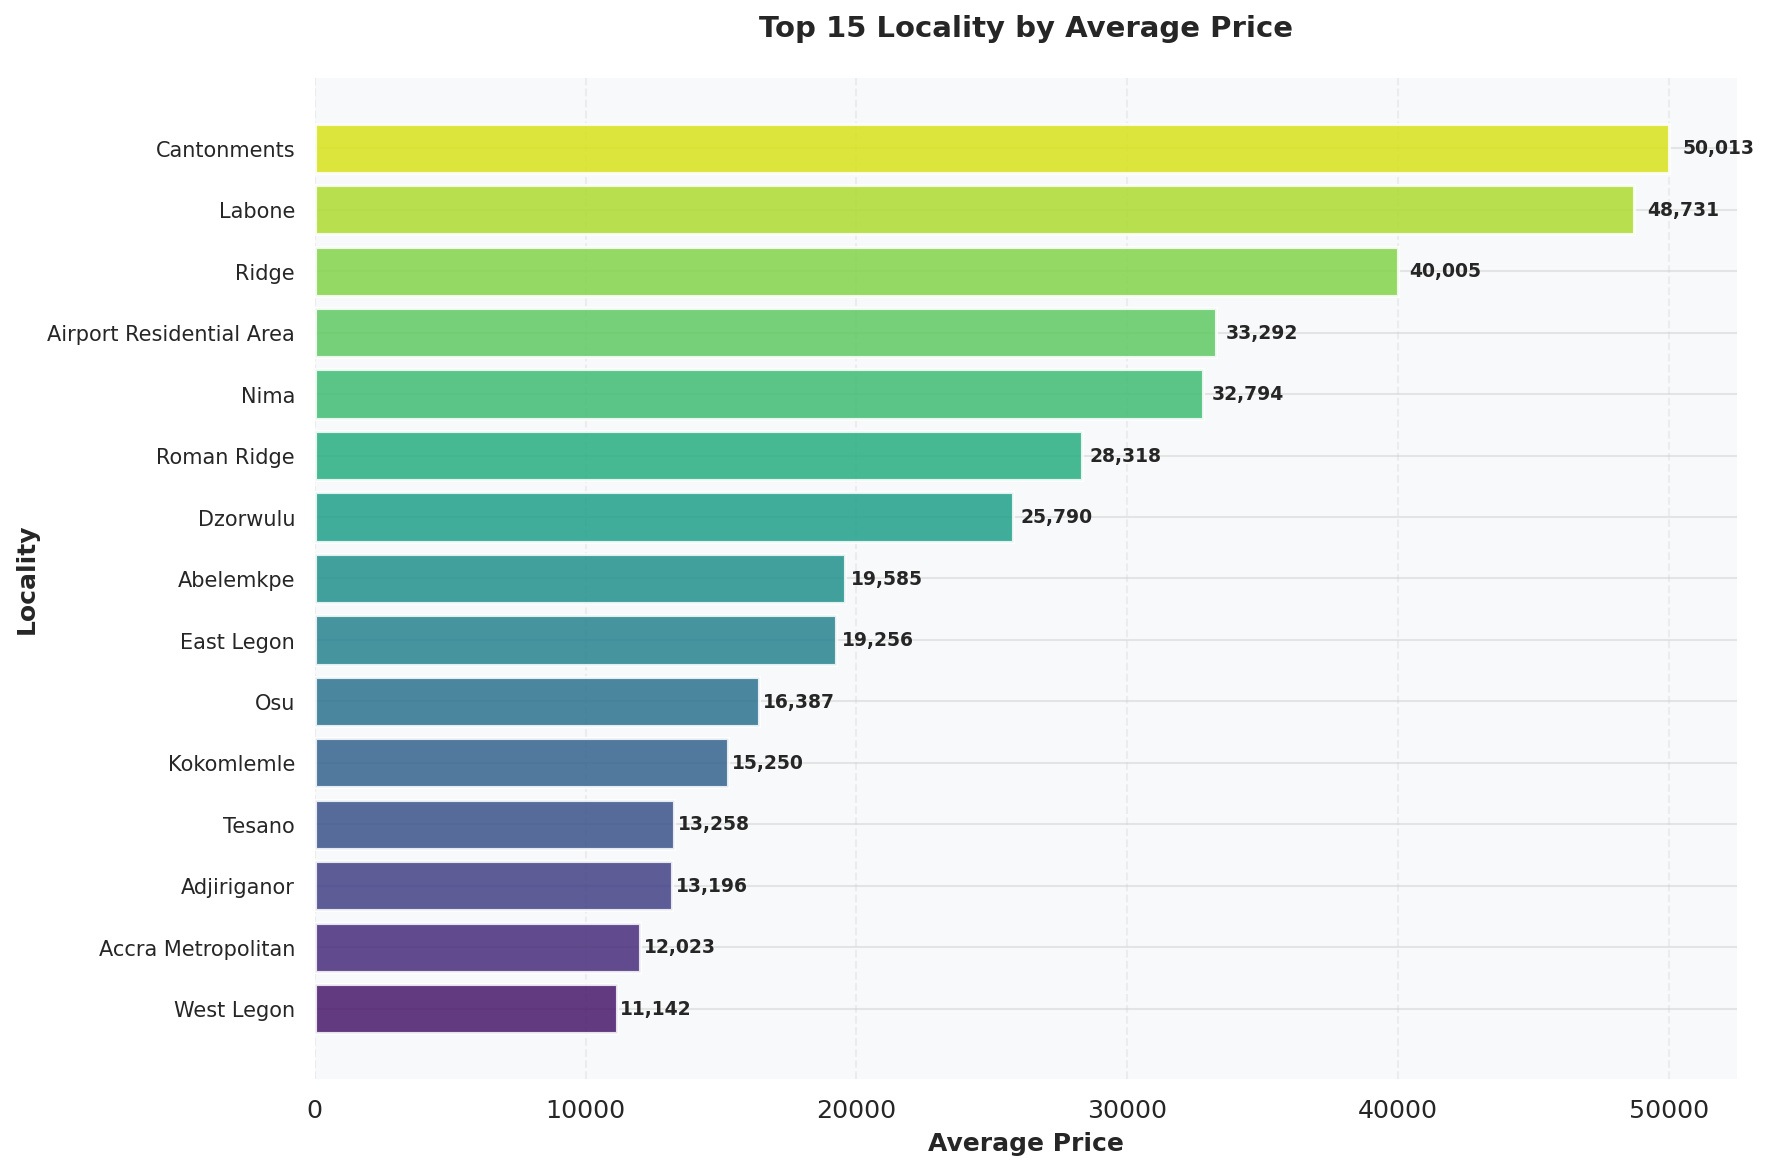

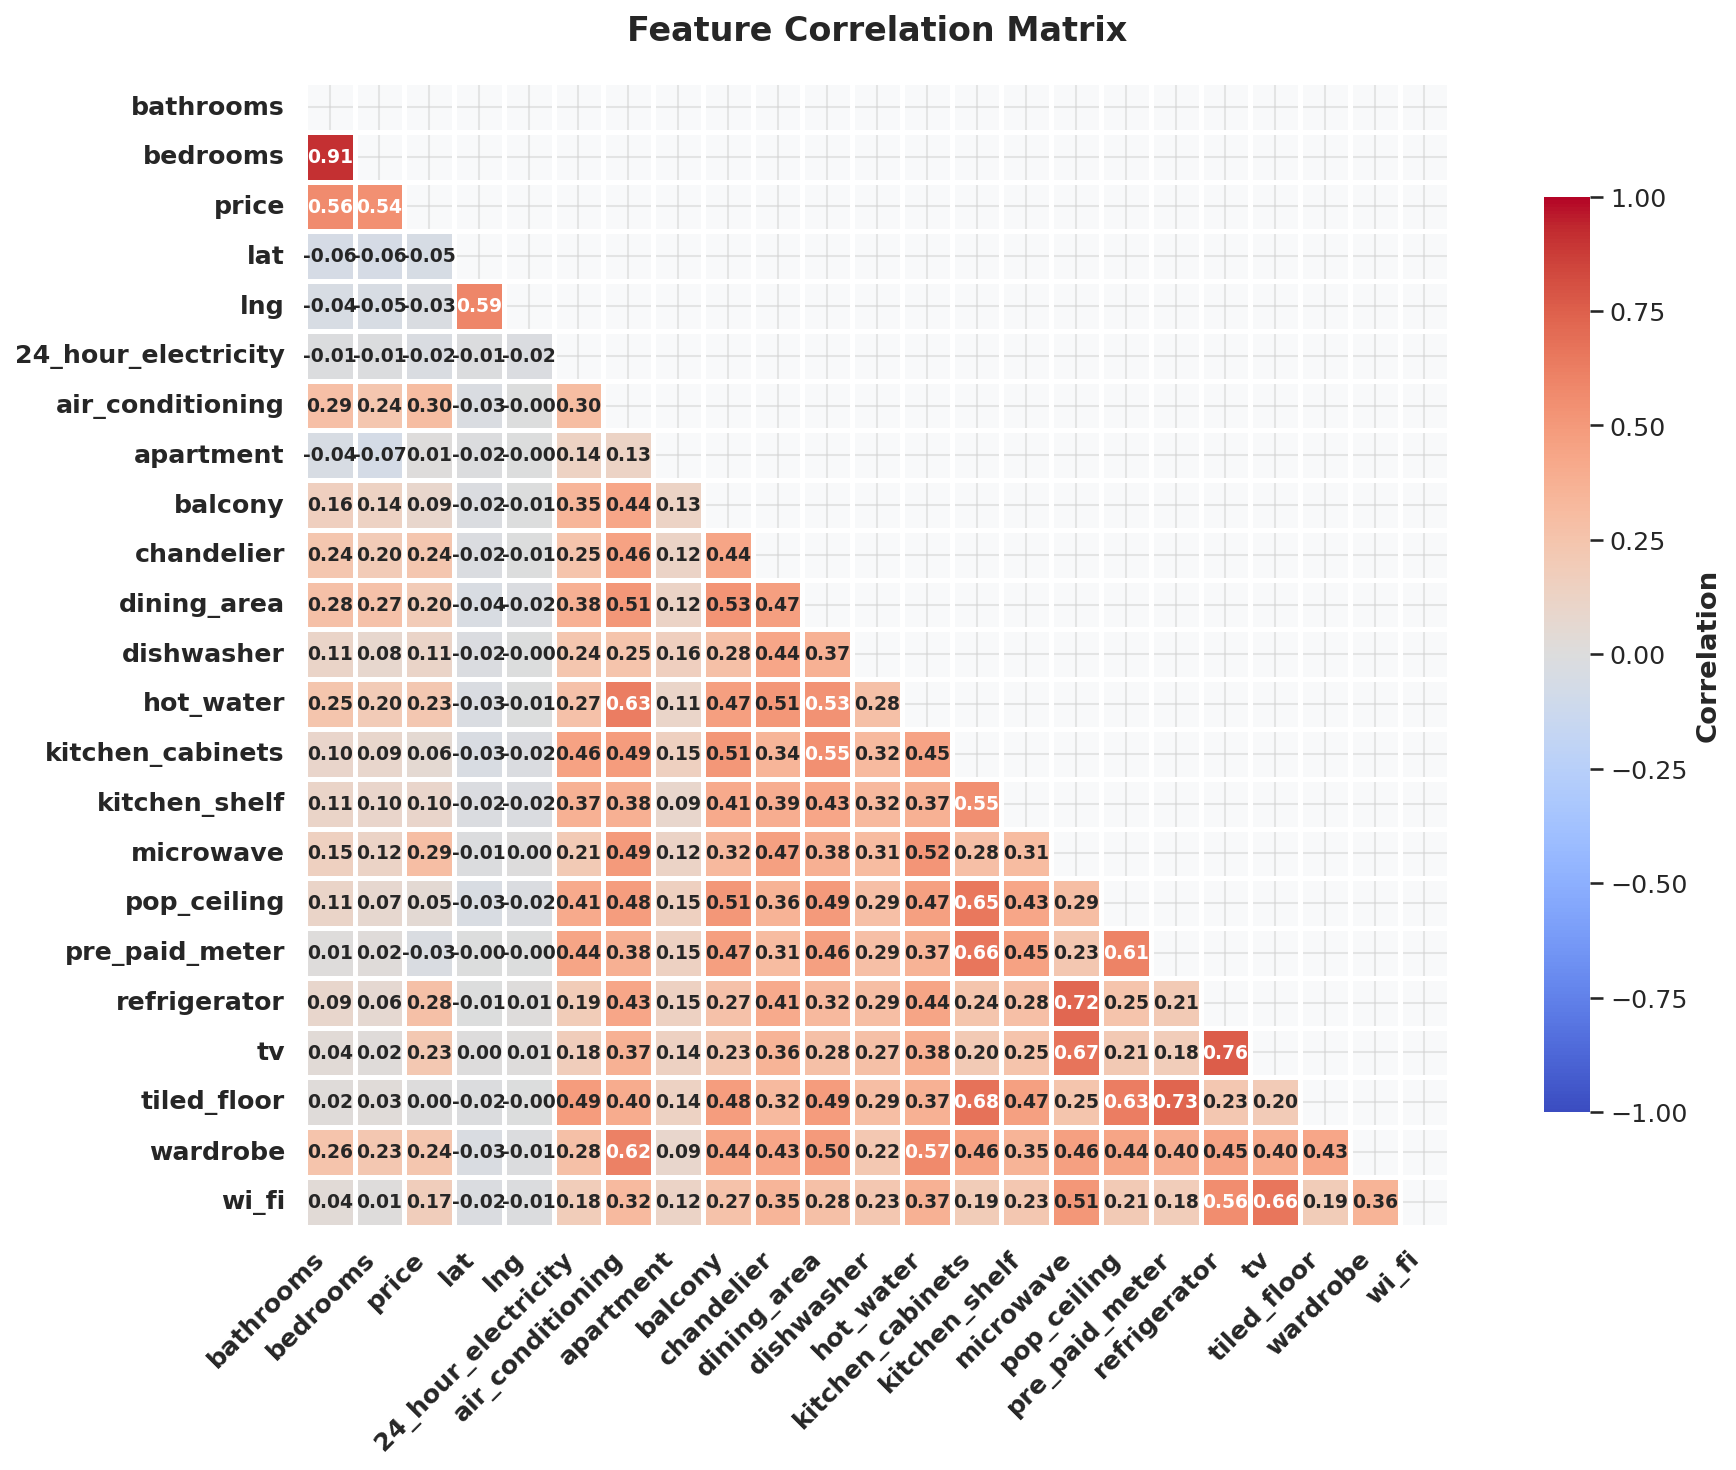

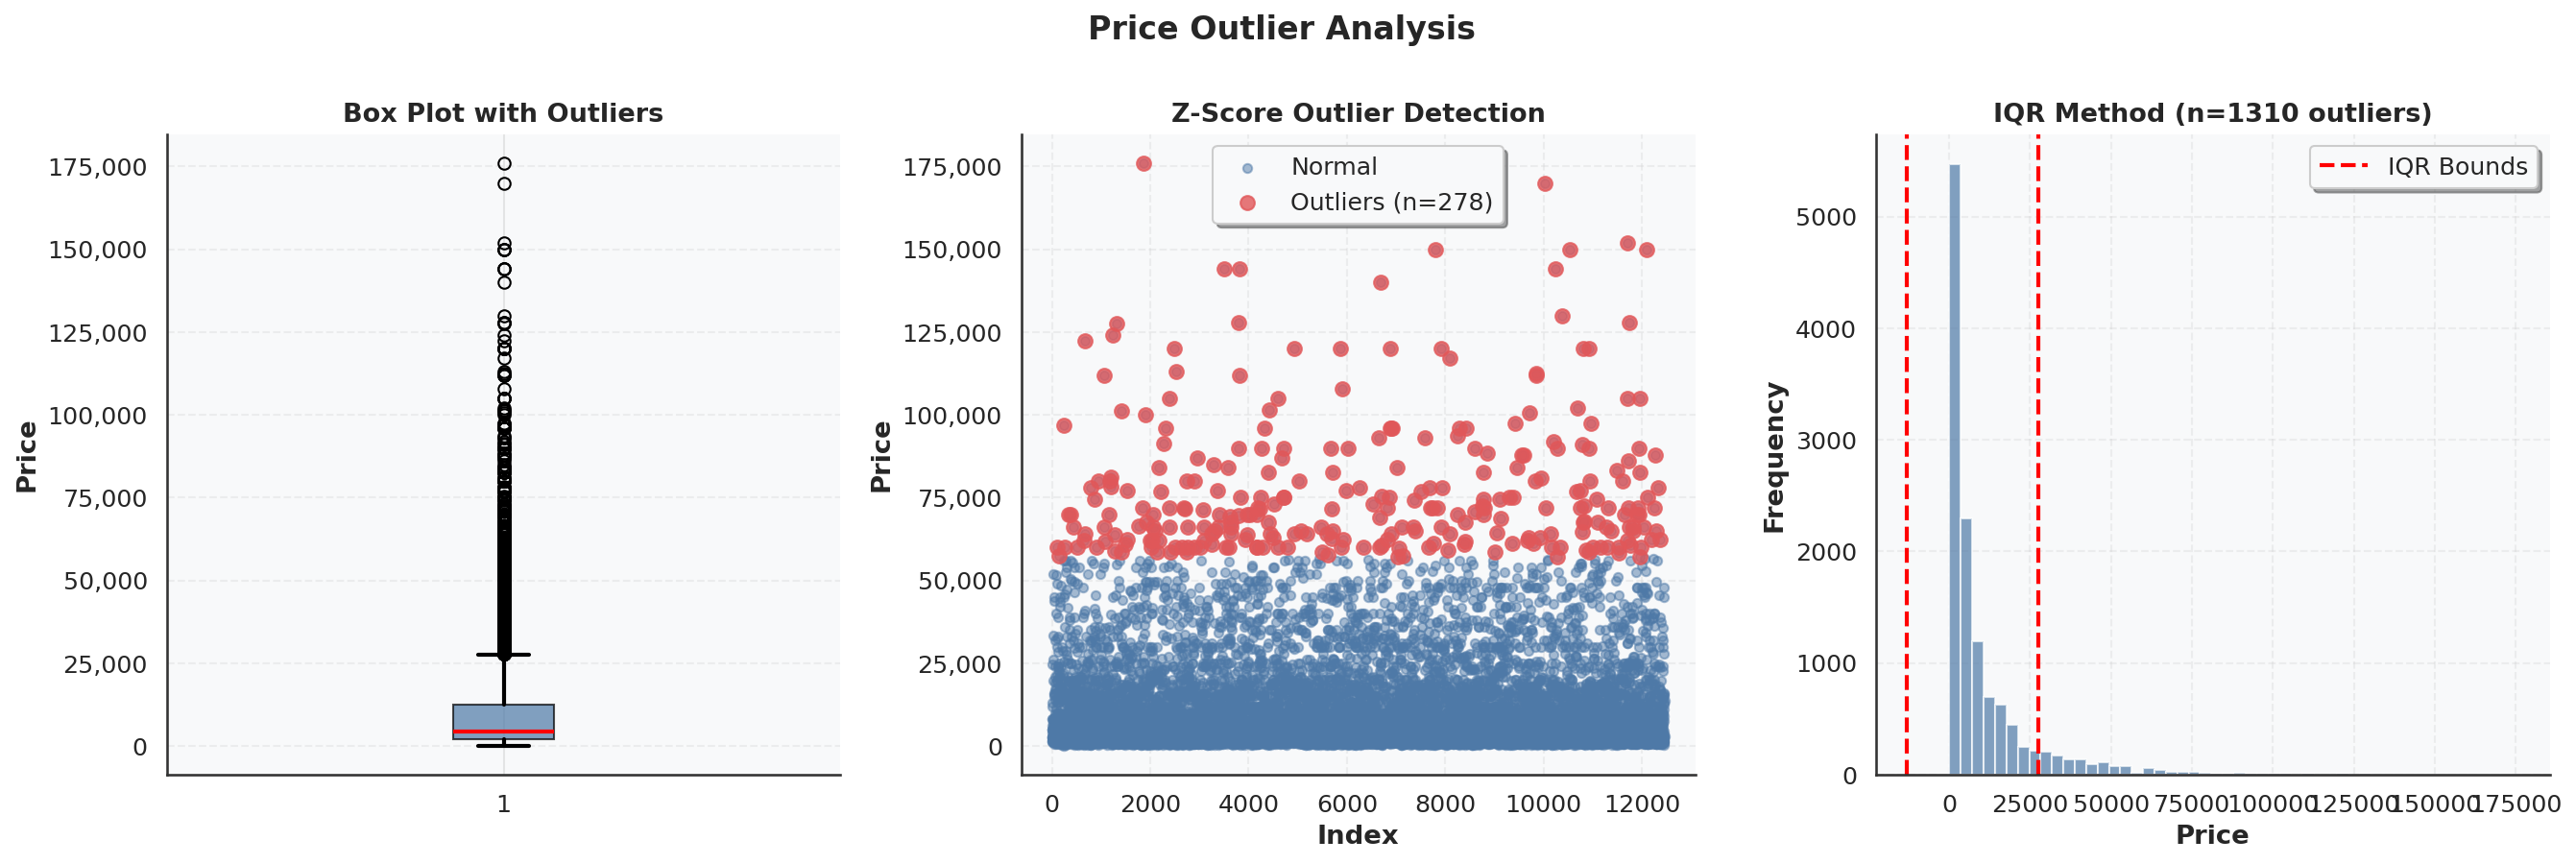


Outlier Summary:
Z-score method (>3): 278 outliers (2.23%)
IQR method: 1310 outliers (10.51%)


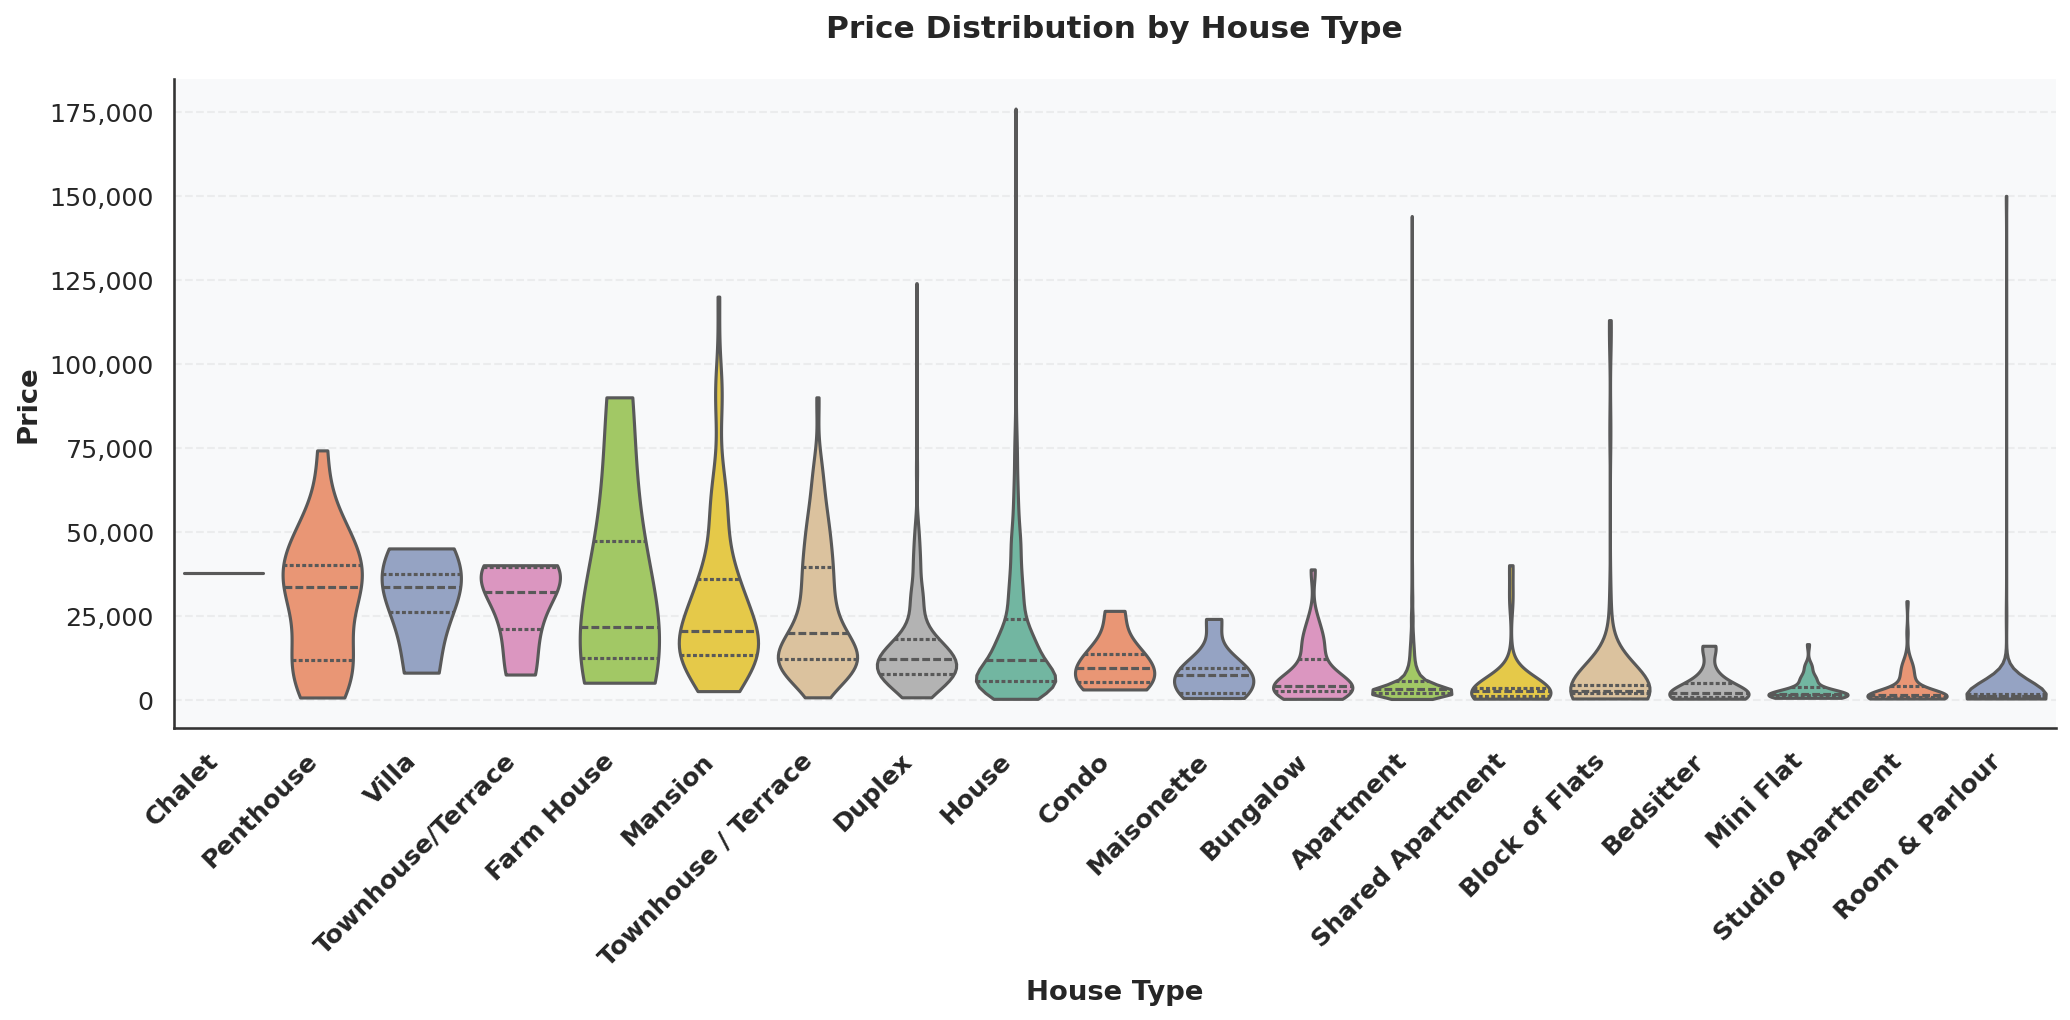

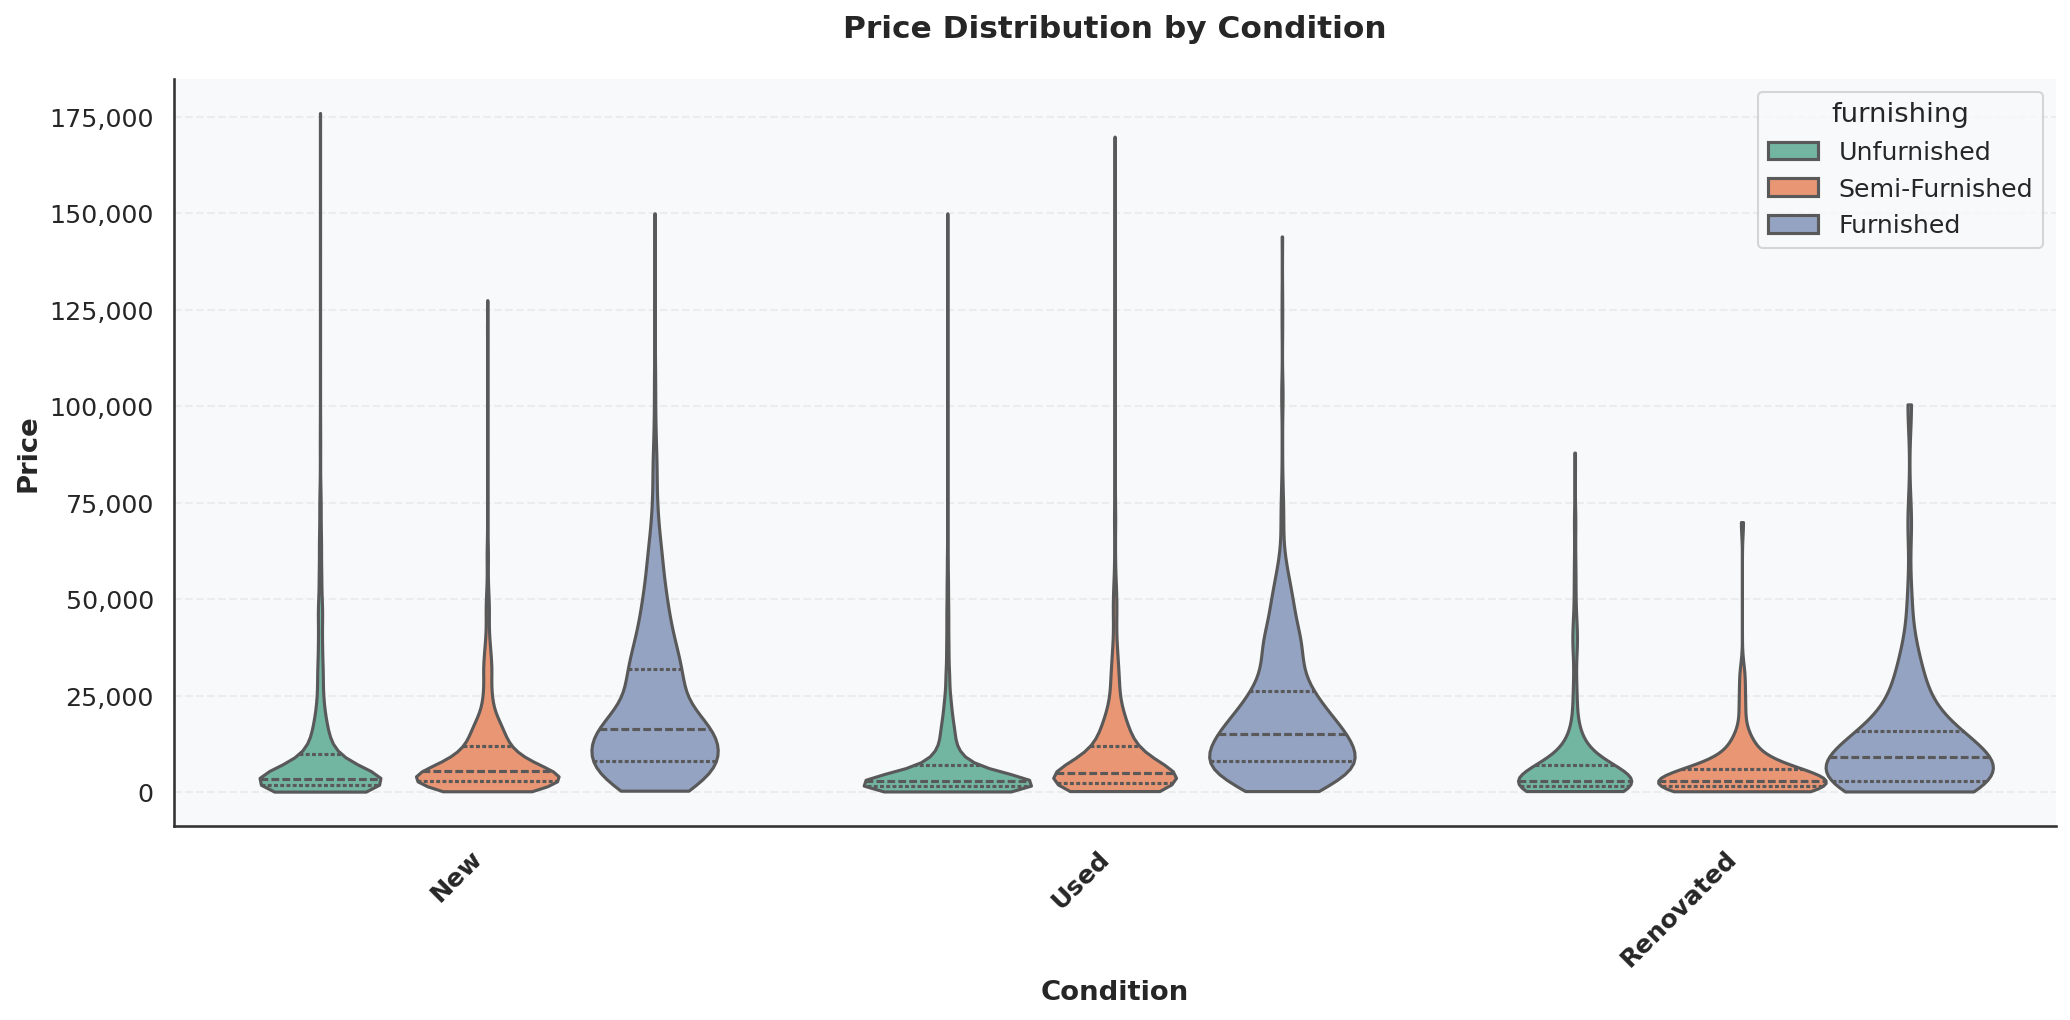

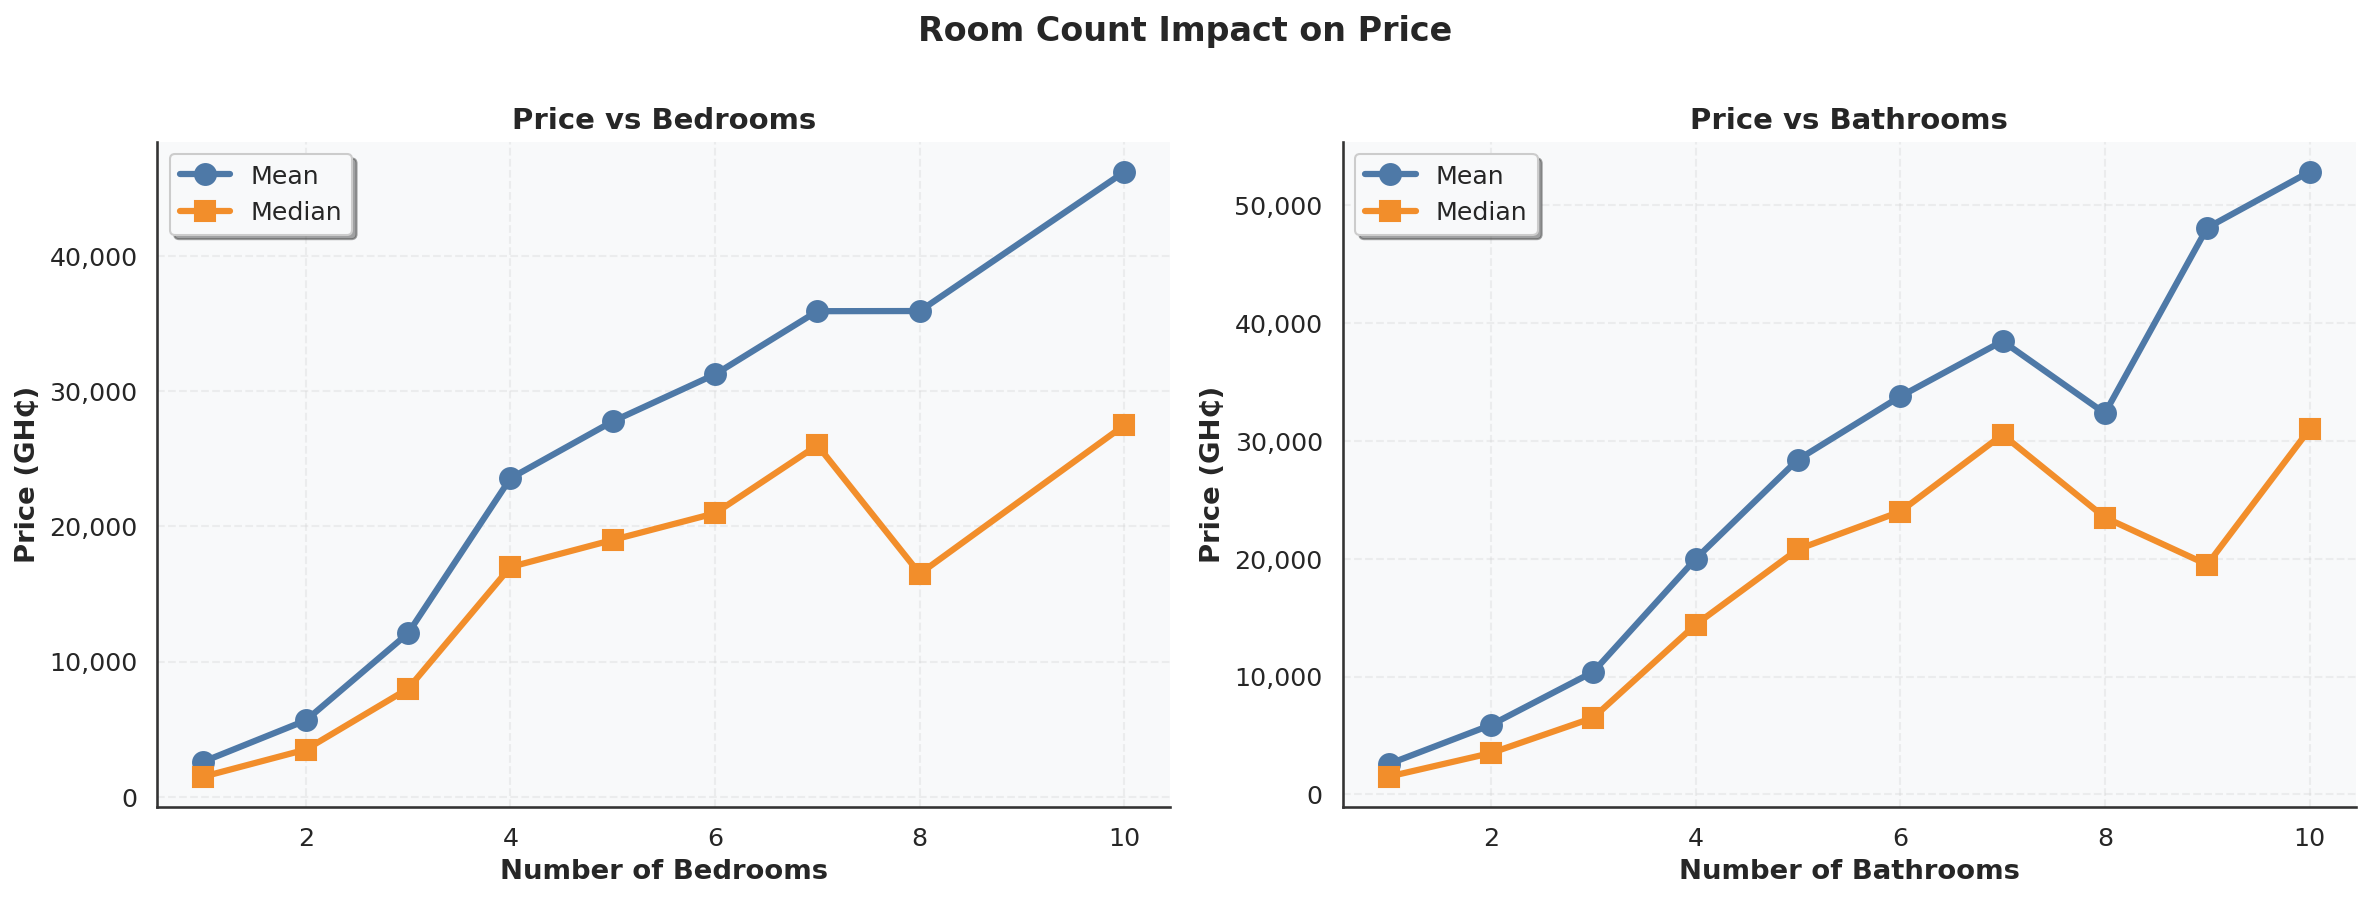

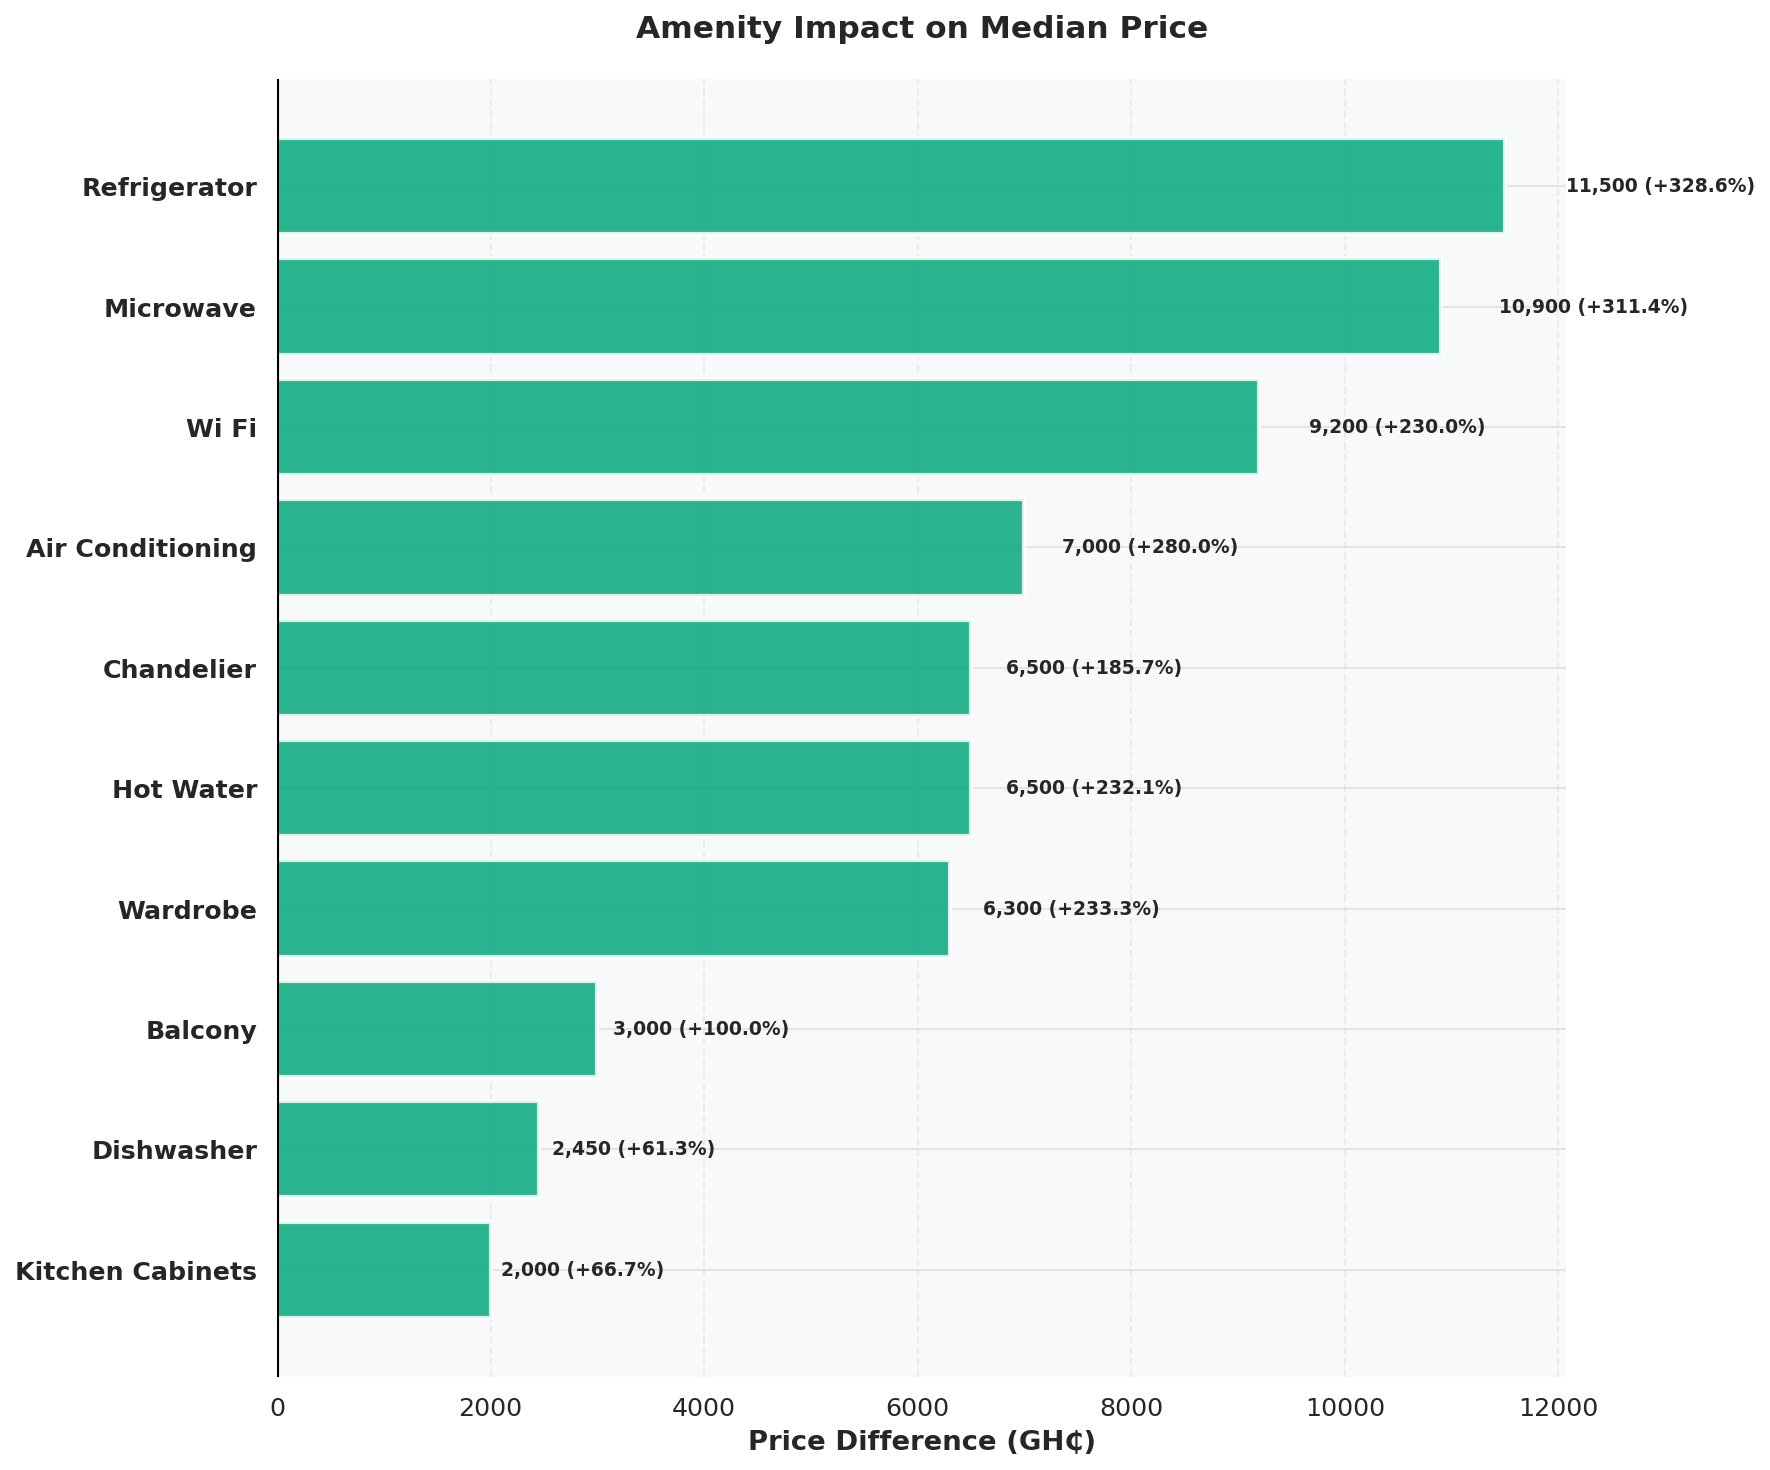

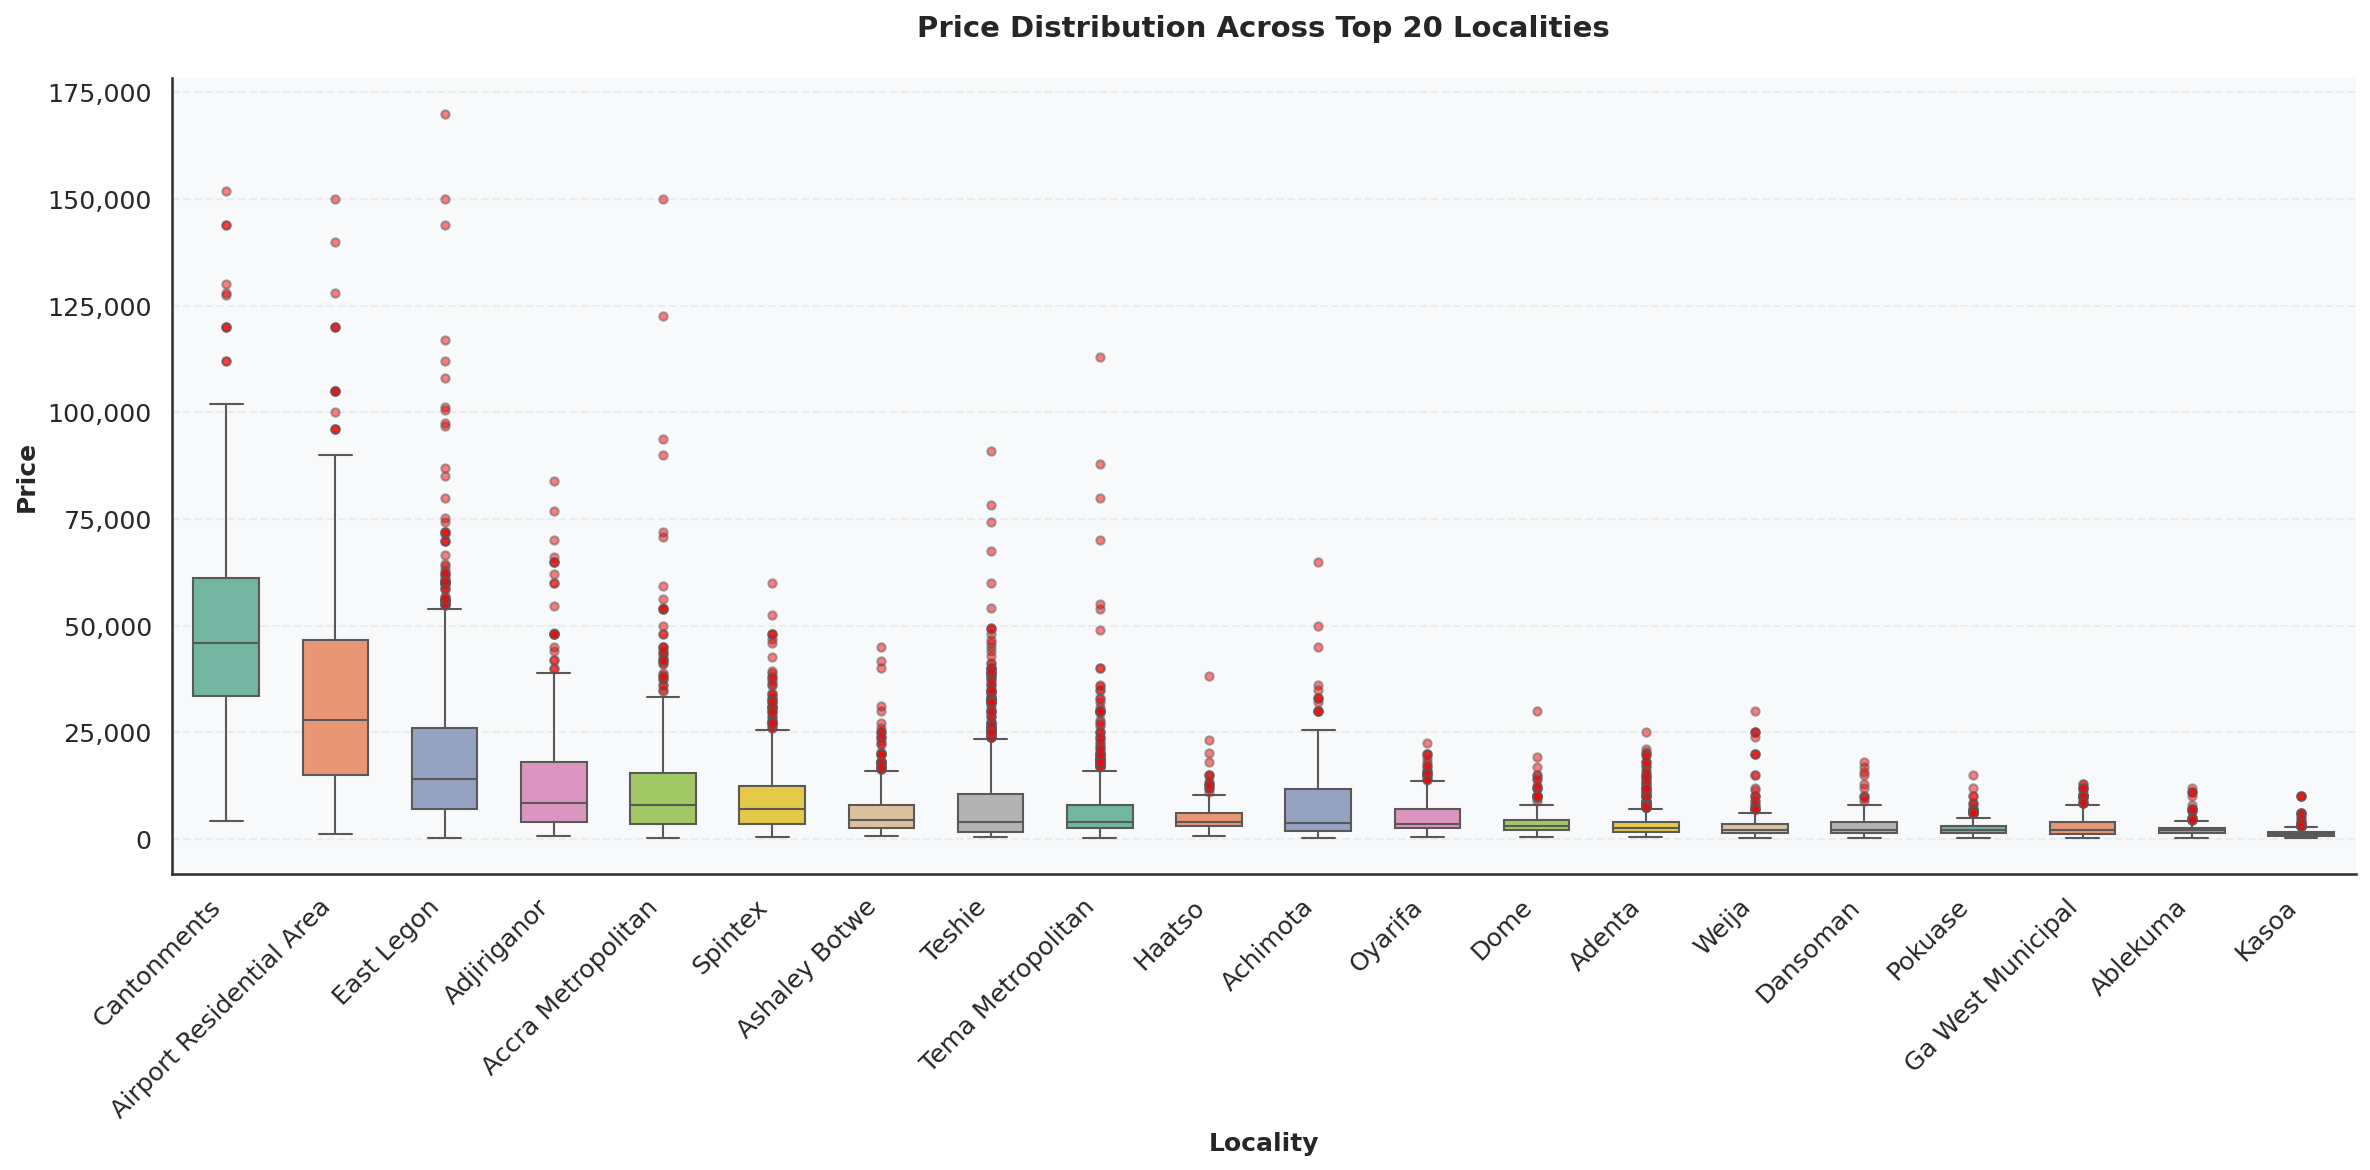

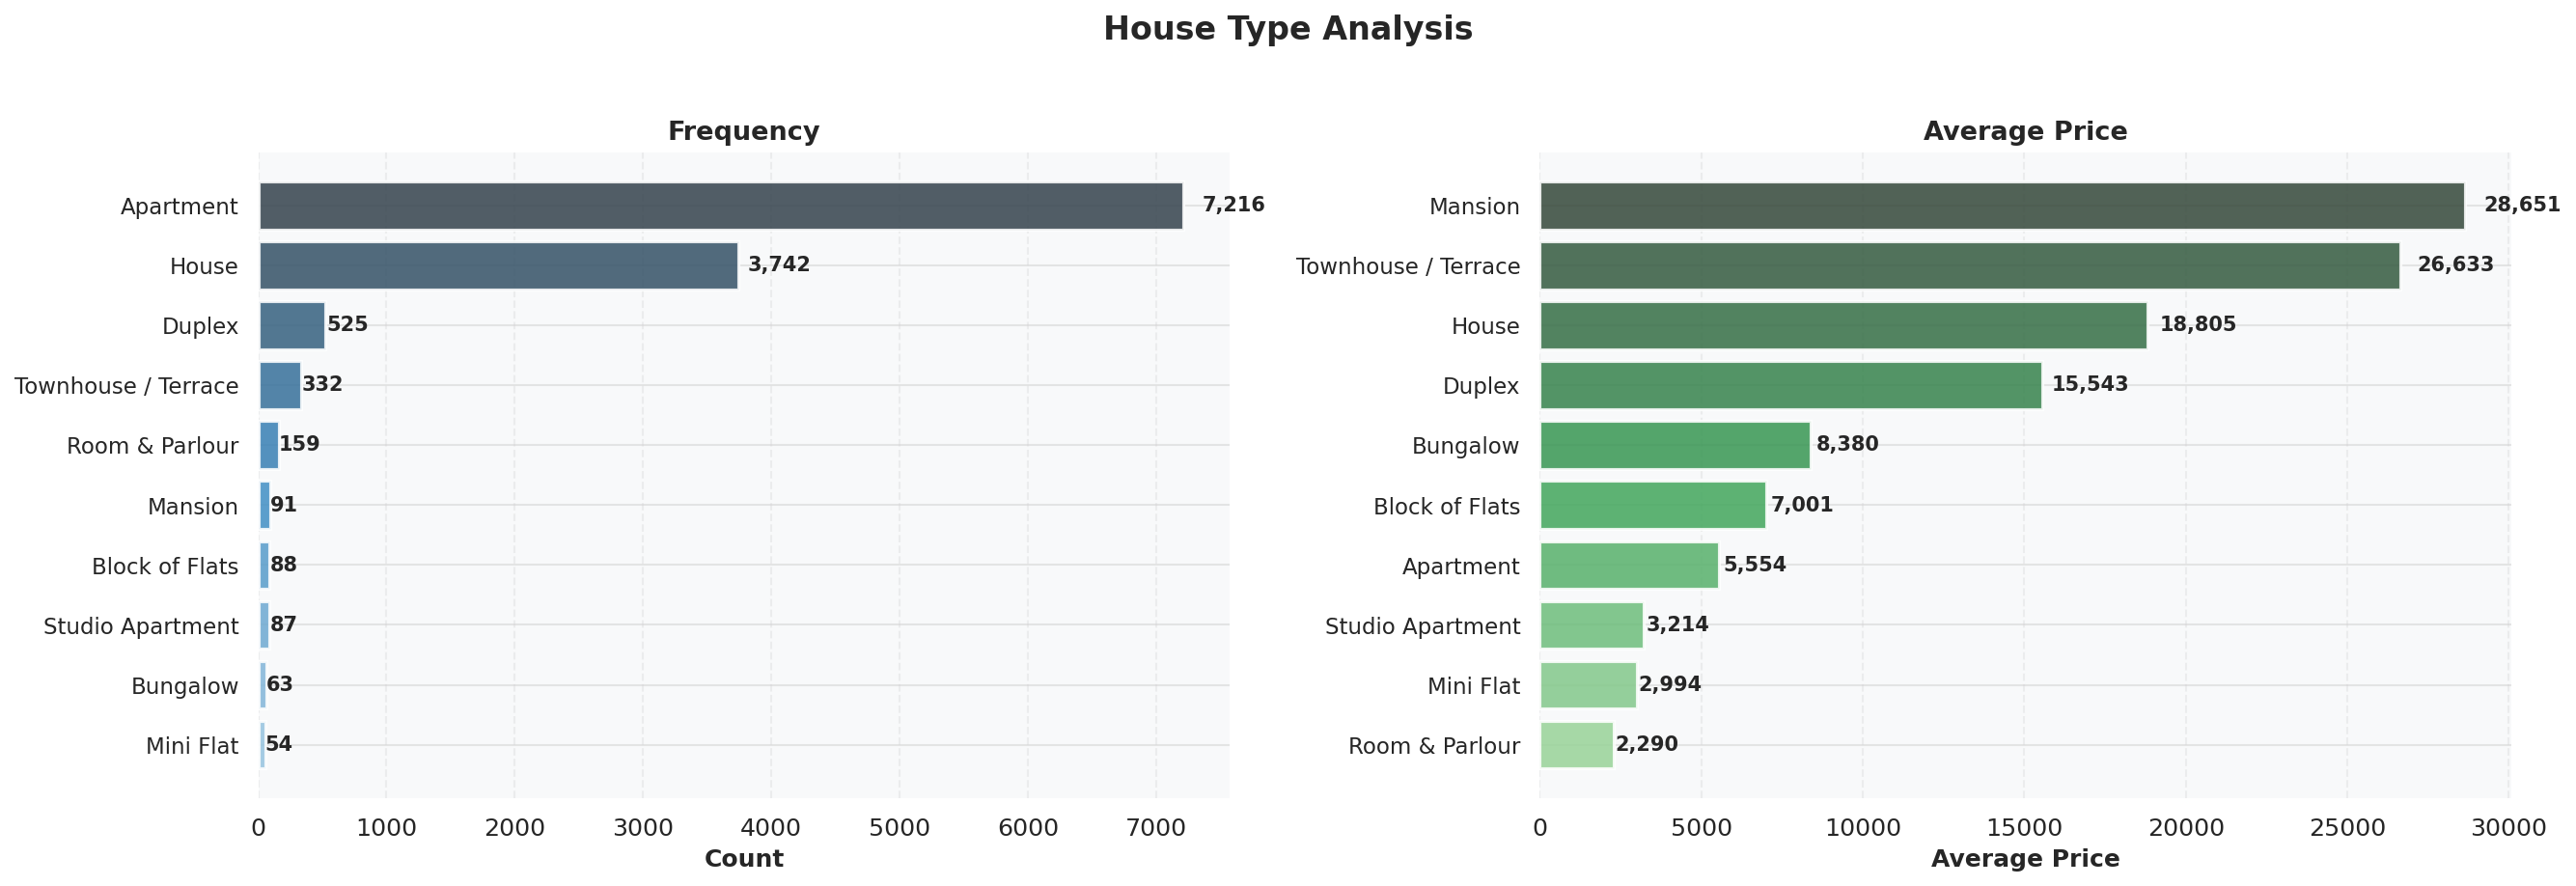

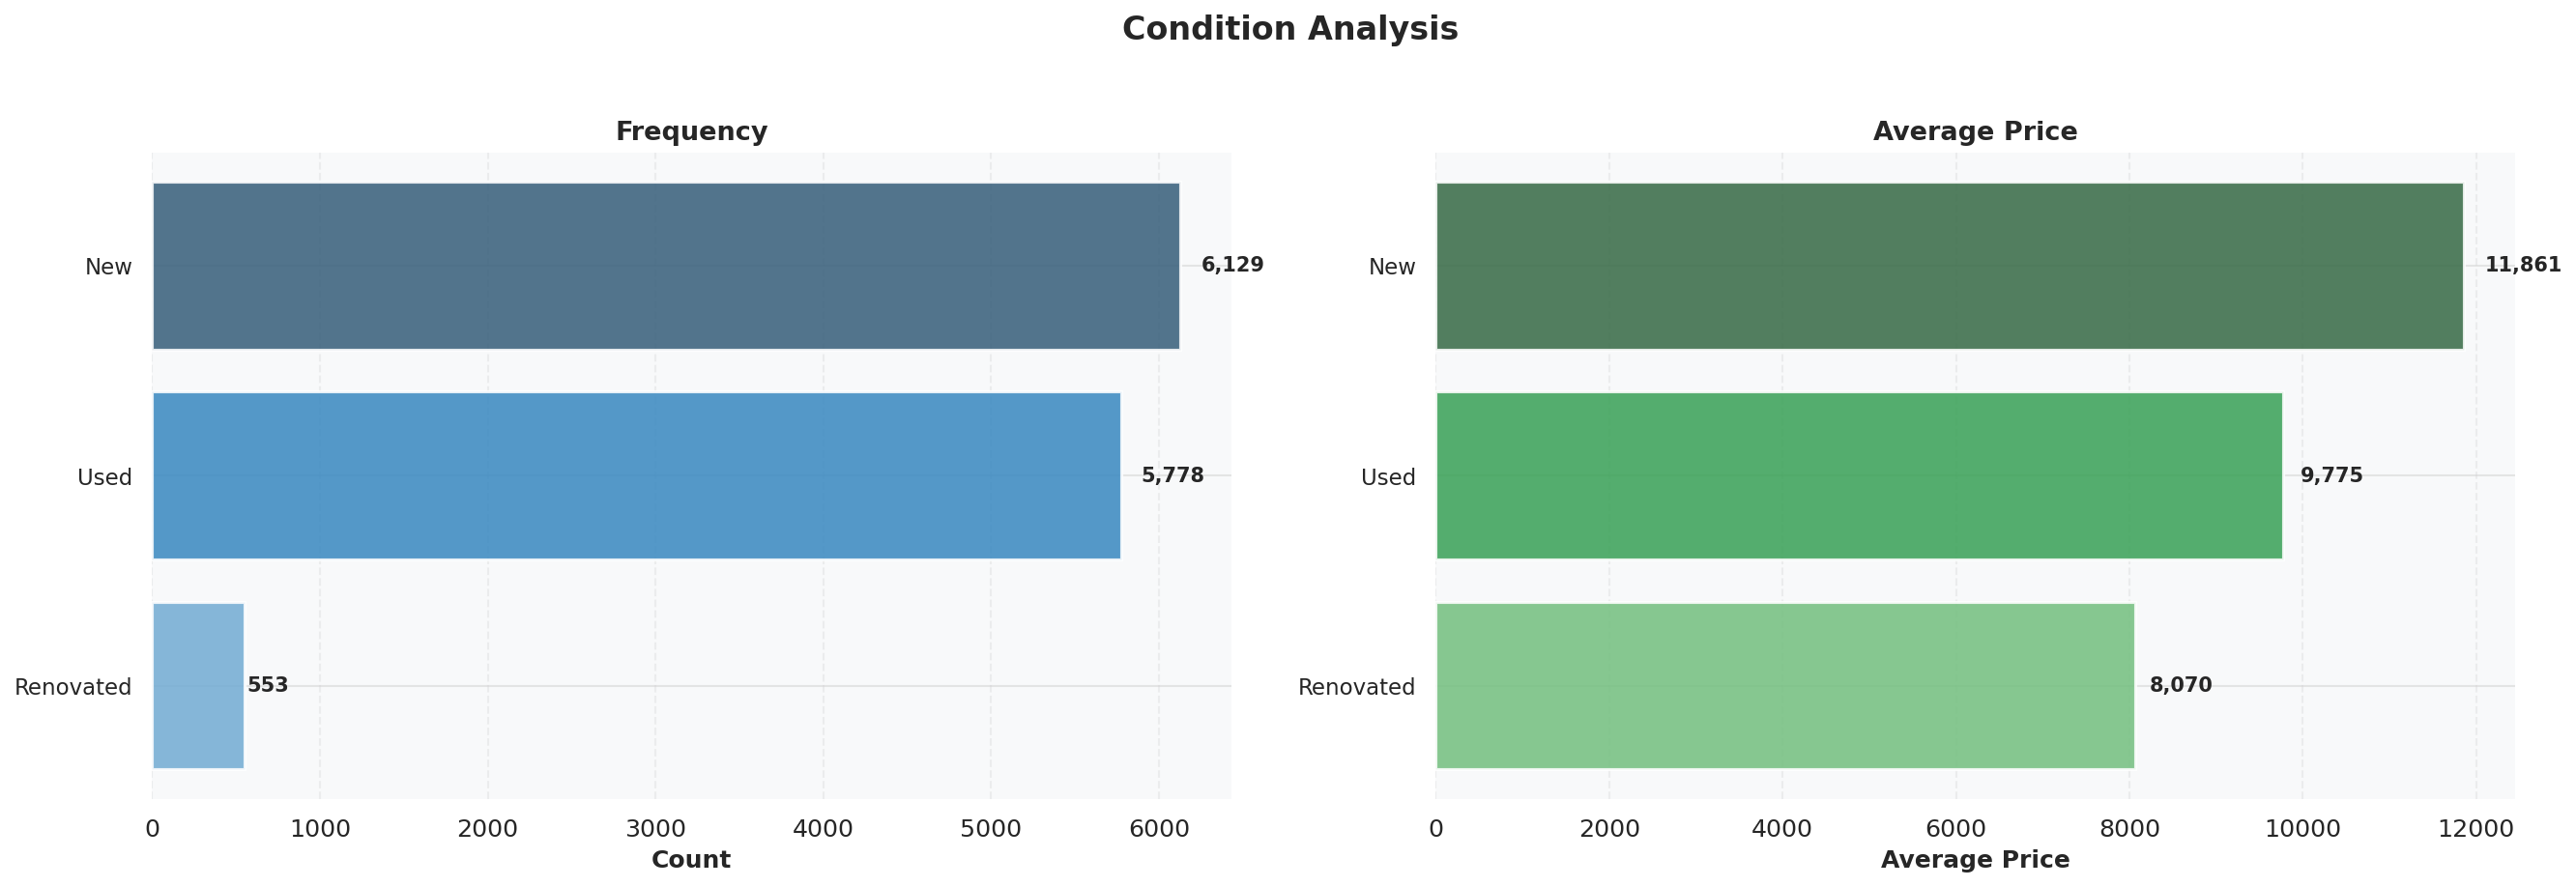

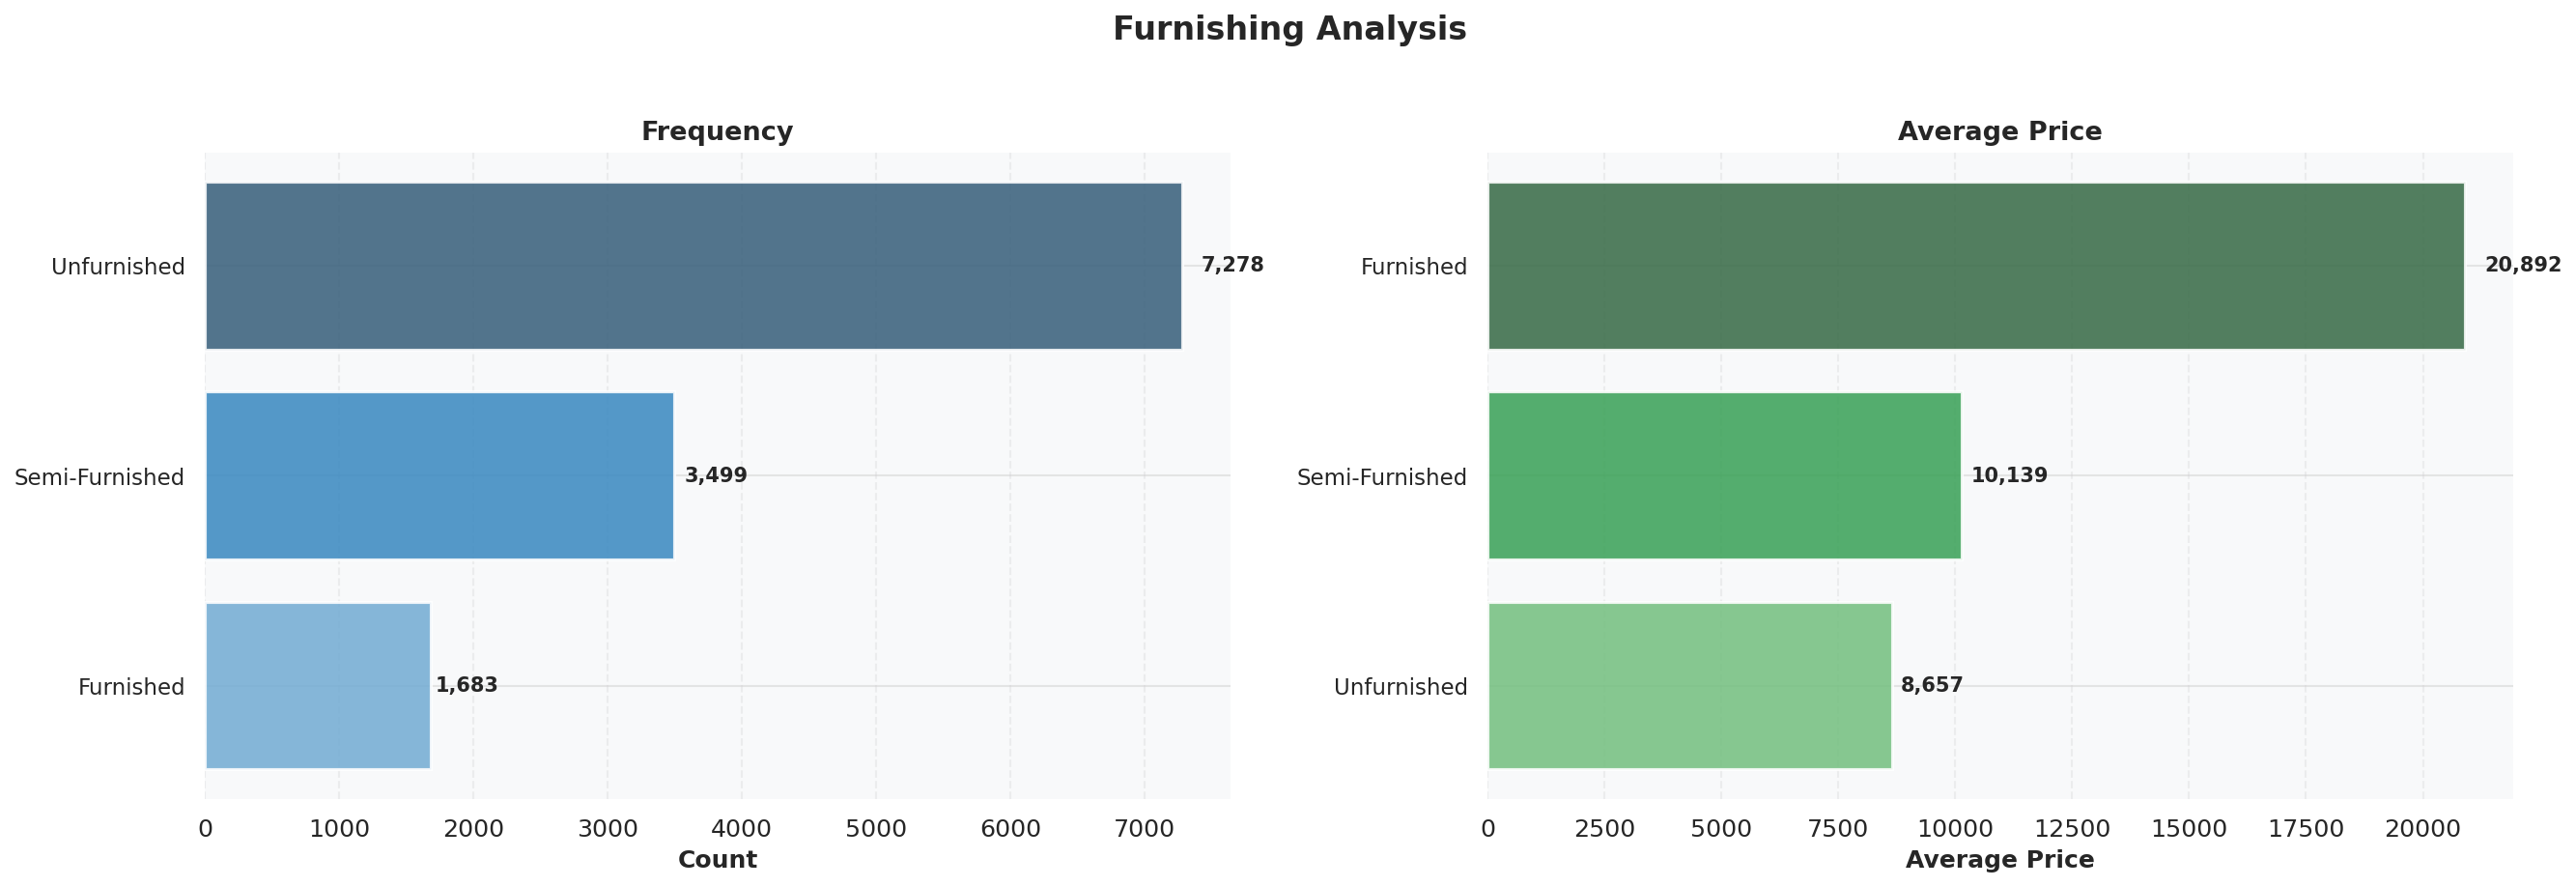

In [9]:
# 1. Price distributions (combined)
plot_combined_distribution(df, "price")

# 2. Top localities pie chart
plot_top_categories_pie(
    df, "locality", top_n=20, title="Top 20 Localities Distribution"
)

# 3. Price by locality
plot_categorical_vs_numeric(df, "locality", "price", top_n=15)

plot_correlation_heatmap(df)

# Usage
plot_outliers_analysis(df, "price")

# Usage
plot_violin_by_categories(df, "house_type", "price")
plot_violin_by_categories(df, "condition", "price", hue_col="furnishing")

plot_price_vs_rooms(df)

amenity_cols = [
    "air_conditioning",
    "hot_water",
    "wi_fi",
    "wardrobe",
    "kitchen_cabinets",
    "refrigerator",
    "microwave",
    "dishwasher",
    "balcony",
    "chandelier",
]
plot_amenity_price_impact(df, amenity_cols)

# 4. Boxplot for localities
plot_boxplot_by_category(
    df,
    "locality",
    "price",
    top_n=20,
    title="Price Distribution Across Top 20 Localities",
)

# 5. House type analysis (combined)
plot_combined_categorical_analysis(df, "house_type", "price", top_n=10)

# 6. Condition analysis (combined)
plot_combined_categorical_analysis(df, "condition", "price")

# 7. Furnishing analysis (combined)
plot_combined_categorical_analysis(df, "furnishing", "price")
